# Database provisioning — n=30 scale analysis

Post-hoc analysis of the scale run on the platform sandbox (Docker always
present; no `stock` / `docker-host` environment axis).

- Experiment: `database-provisioning-v2`
- Run request: `01KZXXQ2JPNK4XX5377TF3V8E6` (terminal: 443 complete, 7 errored)
- Matrix: 5 extensions × 3 databases × n=30 (**450 trials**)
- Extensions: Claude + Sonnet, Cursor + Sonnet, Cursor + Grok 4.5,
  Cursor + Terra, Codex + Terra
- Luna is not in this request
- Snapshot: 2026-08-13, **443/450** measurement rows ($61.32, mean $0.138/run)
- Missing 7 are terminal, not queued: 3 Cursor + Grok / SQLite (2 starved, 1
  sandbox timeout), 2 Cursor + Sonnet / MongoDB (timeout), 1 Cursor + Sonnet /
  SQLite (timeout), 1 Cursor + Terra / SQLite (timeout in sandbox)
- n=5 predecessor: `01KZXQNVBT2EYND880NRVHR7BY`

This notebook follows the analysis plan in
`docs/database-provisioning/technical-design.md` (job completion, provisioning
method, efficiency, Pareto) and the data-viz list in
`docs/database-provisioning/experiment-design-scope.md`. Turns are treated as a
first-class efficiency metric, not an afterthought.

Queries return derived metrics and boolean evidence, not raw URIs or tool
payloads.


Install analysis dependencies into the active kernel (the project `.venv` if
that is selected). Then re-run the next cell.

`ax auth status` should show a signed-in org. Offline alternative:
`ax run download 01KZXXQ2JPNK4XX5377TF3V8E6`, then set `AX_PARQUET_DIR` to the
resulting `.axp/downloads/<id>/` directory.


In [1]:
import importlib.util
import subprocess
import sys

needed = ["requests", "pandas", "matplotlib", "numpy", "dotenv"]
missing = [name for name in needed if importlib.util.find_spec(name) is None]
if missing:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "requests", "pandas", "matplotlib", "numpy", "python-dotenv"]
    )
else:
    print("Skipping pip; using project .venv packages.")


Skipping pip; using project .venv packages.


In [2]:
from __future__ import annotations

import json
import os
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display

%matplotlib inline

EXPERIMENT_ID = "database-provisioning-v2"
RUN_REQUEST_ID = "01KZXXQ2JPNK4XX5377TF3V8E6"
EXPECTED_TRIALS = 450
AX_API_BASE = os.environ.get("AX_API_BASE", "https://app.514.ax").rstrip("/")
AX_PARQUET_DIR = os.environ.get("AX_PARQUET_DIR", "")
CLI_CREDENTIALS_PATH = Path.home() / ".fiveonefour/axp/credentials.toml"

DATABASE_ORDER = ["mongodb", "postgresql", "sqlite"]
HARNESS_ORDER = ["claude", "cursor", "codex"]
EXTENSION_ORDER = [
    "claude-sonnet",
    "cursor-sonnet",
    "cursor-grok",
    "cursor-terra",
    "codex-terra",
]
MODEL_ORDER = ["claude-sonnet-5", "grok-4.5", "gpt-5.6-terra"]
METHOD_ORDER = [
    "container",
    "os-package-manager",
    "official-binary-archive",
    "language-package-runtime",
    "built-in-library",
    "preinstalled-runtime",
    "unknown",
]
OUTCOME_ORDER = ["verified", "unverified", "unscored"]
DISPLAY_NAMES = {
    "mongodb": "MongoDB",
    "postgresql": "PostgreSQL",
    "sqlite": "SQLite",
    "claude": "Claude Code",
    "cursor": "Cursor",
    "codex": "Codex",
    "claude-sonnet-5": "Sonnet 5",
    "grok-4.5": "Grok 4.5",
    "gpt-5.6-terra": "GPT-5.6 Terra",
    "claude-sonnet": "Claude + Sonnet",
    "cursor-sonnet": "Cursor + Sonnet",
    "cursor-grok": "Cursor + Grok 4.5",
    "cursor-terra": "Cursor + Terra",
    "codex-terra": "Codex + Terra",
    "verified": "verified",
    "unverified": "unverified",
    "unscored": "unscored",
    "unknown": "unknown",
}
COLORS = {
    "mongodb": "#00A35C",
    "postgresql": "#336791",
    "sqlite": "#8C8C8C",
    "claude": "#D97706",
    "cursor": "#7C3AED",
    "codex": "#111827",
    "claude-sonnet": "#D97706",
    "cursor-sonnet": "#F59E0B",
    "cursor-grok": "#7C3AED",
    "cursor-terra": "#0EA5E9",
    "codex-terra": "#111827",
}
METHOD_COLORS = {
    "container": "#2563EB",
    "os-package-manager": "#F59E0B",
    "official-binary-archive": "#DC2626",
    "language-package-runtime": "#7C3AED",
    "built-in-library": "#00A35C",
    "preinstalled-runtime": "#6B7280",
    "unknown": "#D1D5DB",
}
OUTCOME_COLORS = {
    "verified": "#00A35C",
    "unverified": "#DC2626",
    "unscored": "#9CA3AF",
}
EXTENSION_FROM_AGENT_MODEL = {
    ("claude", "claude-sonnet-5"): "claude-sonnet",
    ("cursor", "claude-sonnet-5"): "cursor-sonnet",
    ("cursor", "grok-4.5"): "cursor-grok",
    ("cursor", "gpt-5.6-terra"): "cursor-terra",
    ("codex", "gpt-5.6-terra"): "codex-terra",
}

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)

def _load_dotenv() -> None:
    try:
        from dotenv import load_dotenv
    except ImportError:
        return
    here = Path.cwd().resolve()
    for directory in [here, *here.parents]:
        env_file = directory / ".env"
        if env_file.is_file():
            load_dotenv(env_file)
            return


def _credentials_from_cli_store() -> dict[str, str]:
    """Read key names from the AX CLI store. Never print values."""
    if not CLI_CREDENTIALS_PATH.is_file():
        return {}
    values: dict[str, str] = {}
    for line in CLI_CREDENTIALS_PATH.read_text().splitlines():
        stripped = line.strip()
        if not stripped or stripped.startswith("#") or stripped.startswith("["):
            continue
        if "=" not in stripped:
            continue
        key, value = stripped.split("=", 1)
        values[key.strip()] = value.strip().strip('"').strip("'")
    return values


_load_dotenv()
AX_ORG_ID = os.environ.get("AX_ORG_ID", "org_3FJv0fCt81VIGxO61n6HNbYLnHl")


def _api_key() -> str:
    key = os.environ.get("AX_API_KEY") or os.environ.get("AXP_API_KEY")
    if not key:
        key = _credentials_from_cli_store().get("api_key")
    if not key:
        raise RuntimeError(
            "No AX API key in AX_API_KEY / AXP_API_KEY, a repo .env, or "
            f"{CLI_CREDENTIALS_PATH}. Run `ax auth login` or create a token at "
            "https://app.514.ax/account/api-keys."
        )
    return key


def _parse_query_response(response: requests.Response) -> pd.DataFrame:
    text = response.text.strip()
    if not text:
        return pd.DataFrame()

    try:
        payload = response.json()
    except ValueError:
        rows = [json.loads(line) for line in text.splitlines() if line.strip()]
        return pd.DataFrame(rows)

    if isinstance(payload, list):
        return pd.DataFrame(payload)
    if isinstance(payload, dict):
        for key in ("rows", "data", "result", "results"):
            value = payload.get(key)
            if isinstance(value, list):
                return pd.DataFrame(value)
        if payload.get("sql") or payload.get("error"):
            raise RuntimeError(payload.get("error") or payload)
    raise RuntimeError(f"Unexpected AX query response shape: {type(payload).__name__}")


def ax_http_query(
    sql: str,
    *,
    experiment_id: str = EXPERIMENT_ID,
    run_id: str | None = None,
    limit: int = 10_000,
) -> pd.DataFrame:
    path = (
        f"/api/v1/runs/{run_id}/query"
        if run_id
        else f"/api/v1/experiments/{experiment_id}/query"
    )
    headers = {
        "Authorization": f"Bearer {_api_key()}",
        "Accept": "application/json",
        "Content-Type": "application/json",
    }
    if AX_ORG_ID:
        headers["X-Org-Id"] = AX_ORG_ID
    response = requests.post(
        f"{AX_API_BASE}{path}",
        headers=headers,
        json={"sql": sql, "limit": limit, "format": "json"},
        timeout=120,
    )
    if not response.ok:
        raise RuntimeError(
            f"AX query failed ({response.status_code}): {response.text[:500]}"
        )
    return _parse_query_response(response)


def ax_cli_query(sql: str, *, limit: int = 10_000) -> pd.DataFrame:
    ax = shutil.which("ax")
    if not ax:
        raise FileNotFoundError("ax CLI is not on PATH")
    command = [
        ax,
        "experiment",
        "query",
        EXPERIMENT_ID,
        "sql",
        sql,
        "--format",
        "json",
        "--limit",
        str(limit),
    ]
    if AX_ORG_ID:
        command.extend(["--org", AX_ORG_ID])
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(
            f"ax experiment query failed ({result.returncode}): {result.stderr.strip()[:500]}"
        )
    rows: list[dict] = []
    for line in result.stdout.splitlines():
        stripped = line.strip()
        if not stripped or stripped[0] not in "{[":
            continue
        try:
            parsed = json.loads(stripped)
        except json.JSONDecodeError:
            continue
        if isinstance(parsed, list):
            rows.extend(parsed)
        elif isinstance(parsed, dict):
            rows.append(parsed)
    return pd.DataFrame(rows)


def ax_parquet_query(sql: str) -> pd.DataFrame:
    try:
        import duckdb
    except ImportError as exc:
        raise RuntimeError("Install duckdb to query AX_PARQUET_DIR.") from exc

    root = Path(AX_PARQUET_DIR).expanduser()
    files = sorted(root.rglob("*.parquet"))
    if not files:
        raise FileNotFoundError(f"No parquet files under {root}")

    con = duckdb.connect()
    for path in files:
        con.execute(
            f"CREATE OR REPLACE VIEW {path.stem} AS SELECT * FROM read_parquet(?)",
            [str(path)],
        )
    return con.execute(sql).df()


def ax_query(sql: str, **kwargs) -> pd.DataFrame:
    if AX_PARQUET_DIR:
        return ax_parquet_query(sql)
    if shutil.which("ax"):
        return ax_cli_query(sql, limit=kwargs.get("limit", 10_000))
    return ax_http_query(sql, **kwargs)


def _with_database_column(frame: pd.DataFrame) -> pd.DataFrame:
    if "database" not in frame.columns and "prompt_id" in frame.columns:
        frame = frame.rename(columns={"prompt_id": "database"})
    return frame


def assign_extension(frame: pd.DataFrame) -> pd.DataFrame:
    if frame.empty:
        frame["extension"] = pd.Series(dtype="object")
        return frame
    if "resolved_extend_id" in frame.columns:
        mapped = frame["resolved_extend_id"].fillna("").replace("", np.nan)
    else:
        mapped = pd.Series(np.nan, index=frame.index)
    fallback = [
        EXTENSION_FROM_AGENT_MODEL.get((agent, model), f"{agent}+{model}")
        for agent, model in zip(frame.get("agent", []), frame.get("model", []))
    ]
    frame = frame.copy()
    frame["extension"] = mapped.fillna(pd.Series(fallback, index=frame.index))
    known = [name for name in EXTENSION_ORDER if name in set(frame["extension"])]
    extra = sorted(set(frame["extension"]) - set(EXTENSION_ORDER))
    frame["extension"] = pd.Categorical(
        frame["extension"], categories=known + extra, ordered=True
    )
    return frame


def wilson_interval(successes: float, n: float, z: float = 1.96) -> tuple[float, float, float]:
    if n <= 0:
        return (np.nan, np.nan, np.nan)
    p = successes / n
    z2 = z * z
    denom = 1 + z2 / n
    center = (p + z2 / (2 * n)) / denom
    margin = z * np.sqrt((p * (1 - p) + z2 / (4 * n)) / n) / denom
    return p, max(0.0, center - margin), min(1.0, center + margin)


print(f"Experiment: {EXPERIMENT_ID}")
print(f"Run request: {RUN_REQUEST_ID}")
print(f"Expected trials: {EXPECTED_TRIALS}")
print(f"ax CLI: {shutil.which('ax') or 'not on PATH'}")
print(
    "Query surface: "
    + (
        f"parquet {AX_PARQUET_DIR}"
        if AX_PARQUET_DIR
        else "ax experiment query CLI"
        if shutil.which("ax")
        else f"{AX_API_BASE}/api/v1/experiments/{EXPERIMENT_ID}/query"
    )
)


def label_of(value) -> str:
    return DISPLAY_NAMES.get(str(value), str(value))


def grouped_bars(
    ax,
    frame,
    group,
    column,
    title,
    ylabel,
    percent=False,
    groups=None,
    lo_column=None,
    hi_column=None,
):
    groups = groups or EXTENSION_ORDER
    present = [name for name in groups if name in set(frame[group])]
    x = np.arange(len(DATABASE_ORDER))
    width = 0.8 / max(len(present), 1)
    for index, name in enumerate(present):
        subset = (
            frame[frame[group] == name]
            .set_index("database")
            .reindex(DATABASE_ORDER)
        )
        heights = subset[column].fillna(0).to_numpy(dtype=float)
        positions = x + (index - (len(present) - 1) / 2) * width
        ax.bar(
            positions,
            heights,
            width=width,
            label=label_of(name),
            color=COLORS.get(name, "#6B7280"),
        )
        if lo_column and hi_column and lo_column in subset.columns and hi_column in subset.columns:
            lo = subset[lo_column].fillna(subset[column]).to_numpy(dtype=float)
            hi = subset[hi_column].fillna(subset[column]).to_numpy(dtype=float)
            yerr = np.vstack(
                [
                    np.clip(heights - lo, 0, None),
                    np.clip(hi - heights, 0, None),
                ]
            )
            ax.errorbar(
                positions,
                heights,
                yerr=yerr,
                fmt="none",
                ecolor="#111827",
                elinewidth=1,
                capsize=2,
            )
    ax.set_title(title)
    ax.set_xlabel("Database")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x, [label_of(name) for name in DATABASE_ORDER])
    if percent:
        ax.set_ylim(0, 105)
    ax.legend(frameon=False, fontsize=8, ncol=2)


def stacked_method_bars(ax, frame, index_col, index_order, title):
    present = [name for name in index_order if name in set(frame[index_col])]
    pivot = (
        pd.crosstab(frame[index_col], frame["final_method"])
        .reindex(present, fill_value=0)
        .reindex(columns=[name for name in METHOD_ORDER if name in set(frame["final_method"])], fill_value=0)
    )
    if pivot.empty:
        ax.set_title(title)
        ax.set_axis_off()
        return
    pivot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[METHOD_COLORS.get(column, "#9CA3AF") for column in pivot.columns],
        legend=False,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_xticklabels([label_of(name) for name in pivot.index], rotation=20, ha="right")


Experiment: database-provisioning-v2
Run request: 01KZXXQ2JPNK4XX5377TF3V8E6
Expected trials: 450
ax CLI: /opt/homebrew/bin/ax
Query surface: ax experiment query CLI


## Per-run metrics

Official AX `measurements` for this run request. A run **passes** only when
both `uri-reported` and `connection-verified-in-agent` succeed.

`num_turns` is a first-class efficiency metric here (technical design: runtime,
cost, and turns/tool use). Fewer than 450 rows means the request is still
running, a trial starved, or a harness failed before tests.


In [3]:
per_run_sql = f"""
SELECT
    run_id,
    agent,
    model,
    resolved_extend_id,
    prompt_id,
    repeat_idx,
    status,
    exit_reason,
    test_pass_count,
    test_fail_count,
    agent_time_ms / 1000.0 AS runtime_s,
    num_turns,
    tool_calls_total,
    tool_calls_failed,
    input_tokens,
    output_tokens,
    cost_usd_micros / 1000000.0 AS cost_usd
FROM measurements
WHERE run_request_id = '{RUN_REQUEST_ID}'
ORDER BY agent, model, prompt_id, repeat_idx
"""

runs = assign_extension(_with_database_column(ax_query(per_run_sql)))
READY = not runs.empty
if not READY:
    print(
        f"No measurements yet for {RUN_REQUEST_ID}. "
        "The notebook is scaffolded; re-run from this cell when the request finishes."
    )
else:
    numeric_columns = [
        "repeat_idx",
        "test_pass_count",
        "test_fail_count",
        "runtime_s",
        "num_turns",
        "tool_calls_total",
        "tool_calls_failed",
        "input_tokens",
        "output_tokens",
        "cost_usd",
    ]
    present = [column for column in numeric_columns if column in runs.columns]
    runs[present] = runs[present].apply(pd.to_numeric)
    runs["both_tests_passed"] = runs["status"].eq("pass") | (
        runs["test_pass_count"].fillna(0).ge(2) & runs["test_fail_count"].fillna(0).eq(0)
    )
    runs["database"] = pd.Categorical(runs["database"], categories=DATABASE_ORDER, ordered=True)
    runs["harness"] = pd.Categorical(runs["agent"], categories=HARNESS_ORDER, ordered=True)
    print(
        f"Finished measurement rows: {len(runs)} "
        f"(expected {EXPECTED_TRIALS} if none starved)"
    )
    missing = EXPECTED_TRIALS - len(runs)
    if missing:
        print(
            f"{missing} trials have no measurement row (starved or sandbox timeout). "
            "The request is terminal; charts use finished rows only."
        )
    print(
        "Overall: "
        f"{int(runs['both_tests_passed'].sum())}/{len(runs)} both-tests passed "
        f"({100 * float(runs['both_tests_passed'].mean()):.1f}%), "
        f"total cost ${float(runs['cost_usd'].sum()):.2f}, "
        f"mean ${float(runs['cost_usd'].mean()):.3f}/run, "
        f"mean turns {float(runs['num_turns'].mean()):.2f}."
    )
    display(runs.head())
    print("Pooled completion by database:")
    display(
        runs.groupby("database", observed=True)
        .agg(
            n=("run_id", "size"),
            passed=("both_tests_passed", "sum"),
            pass_rate=("both_tests_passed", "mean"),
            runtime_mean_s=("runtime_s", "mean"),
            turns_mean=("num_turns", "mean"),
            cost_mean_usd=("cost_usd", "mean"),
            cost_total_usd=("cost_usd", "sum"),
        )
        .reindex(DATABASE_ORDER)
        .round(3)
    )

    coverage = (
        runs.groupby(["extension", "database"], observed=True)
        .size()
        .reindex(
            pd.MultiIndex.from_product(
                [EXTENSION_ORDER, DATABASE_ORDER], names=["extension", "database"]
            ),
            fill_value=0,
        )
        .rename("n")
        .reset_index()
    )
    short = coverage[coverage["n"] < 30]
    if short.empty:
        print("Coverage: every scale cell has 30 measurement rows.")
    else:
        short = short.copy()
        short["label"] = short["extension"].map(DISPLAY_NAMES)
        short["database_label"] = short["database"].map(DISPLAY_NAMES)
        print("Cells with n<30 (queued, running, starved, or missing):")
        display(short[["label", "database_label", "n"]])

    print("exit_reason counts:")
    display(runs["exit_reason"].fillna("(null)").value_counts().rename("runs").to_frame())


Finished measurement rows: 443 (expected 450 if none starved)
7 trials have no measurement row (starved or sandbox timeout). The request is terminal; charts use finished rows only.
Overall: 369/443 both-tests passed (83.3%), total cost $61.32, mean $0.138/run, mean turns 2.95.


,run_id,agent,model,resolved_extend_id,database,repeat_idx,status,exit_reason,test_pass_count,test_fail_count,runtime_s,num_turns,tool_calls_total,tool_calls_failed,input_tokens,output_tokens,cost_usd,extension,both_tests_passed,harness
0,claude::anthropic-claude-sonnet-5::mongodb::claude-sonnet::abaa38503ca30b59,claude,claude-sonnet-5,claude-sonnet,mongodb,0,pass,end_turn,2,0,50.466,6,5,0,11,999,0.146153,claude-sonnet,True,claude
1,claude::anthropic-claude-sonnet-5::mongodb::claude-sonnet::c0f8829c432b3486,claude,claude-sonnet-5,claude-sonnet,mongodb,1,pass,end_turn,2,0,59.364,7,6,0,13,1568,0.173868,claude-sonnet,True,claude
2,claude::anthropic-claude-sonnet-5::mongodb::claude-sonnet::eb8d81739dd1b93b,claude,claude-sonnet-5,claude-sonnet,mongodb,2,pass,end_turn,2,0,91.336,11,10,1,21,2834,0.253368,claude-sonnet,True,claude
3,claude::anthropic-claude-sonnet-5::mongodb::claude-sonnet::6a8938c80622f90f,claude,claude-sonnet-5,claude-sonnet,mongodb,3,pass,end_turn,2,0,93.843,7,6,0,13,1617,0.514384,claude-sonnet,True,claude
4,claude::anthropic-claude-sonnet-5::mongodb::claude-sonnet::02fe330358125efa,claude,claude-sonnet-5,claude-sonnet,mongodb,4,pass,end_turn,2,0,46.018,5,4,0,9,1321,0.100847,claude-sonnet,True,claude


Pooled completion by database:


,n,passed,pass_rate,runtime_mean_s,turns_mean,cost_mean_usd,cost_total_usd
database,,,,,,,
mongodb,148,135,0.912,50.936,3.243,0.136,20.076
postgresql,150,110,0.733,46.041,2.833,0.123,18.512
sqlite,145,124,0.855,48.618,2.759,0.157,22.732


Cells with n<30 (queued, running, starved, or missing):


,label,database_label,n
3,Cursor + Sonnet,MongoDB,28
5,Cursor + Sonnet,SQLite,29
8,Cursor + Grok 4.5,SQLite,27
11,Cursor + Terra,SQLite,29


exit_reason counts:


,runs
exit_reason,
end_turn,436
success,4
completed,3


## Official test outcomes

Report `uri-reported` and `connection-verified-in-agent` **separately** (technical
design). A run-level pass requires both. Readiness-only evidence (`pg_isready` /
TCP) does not pass connection-verified.

Do not compute an independent connection-acceptance rate; AX tests cannot reach
the agent-started process.


In [4]:
if not READY:
    tests = pd.DataFrame()
    failures = pd.DataFrame()
    print("Waiting for measurements.")
else:
    tests_sql = f"""
    SELECT
        agent,
        model,
        resolved_extend_id,
        prompt_id,
        repeat_idx,
        test_name,
        exit_code = 0 AS passed,
        exit_code
    FROM test_output
    WHERE run_request_id = '{RUN_REQUEST_ID}'
    ORDER BY agent, model, prompt_id, repeat_idx, test_name
    """
    tests = assign_extension(_with_database_column(ax_query(tests_sql)))
    tests["repeat_idx"] = pd.to_numeric(tests["repeat_idx"])
    tests["exit_code"] = pd.to_numeric(tests["exit_code"])
    tests["passed"] = tests["passed"].astype(bool)
    tests["database"] = pd.Categorical(tests["database"], categories=DATABASE_ORDER, ordered=True)

    test_summary = (
        tests.groupby(["extension", "database", "test_name"], observed=True)["passed"]
        .agg(passes="sum", n="count", rate="mean")
        .reset_index()
    )
    test_summary["rate_pct"] = test_summary["rate"] * 100
    print("Official tests by extension × database (separate scores):")
    display(test_summary)

    failures_sql = f"""
    SELECT
        agent,
        model,
        resolved_extend_id,
        prompt_id,
        repeat_idx,
        test_name,
        exit_code,
        stderr_tail
    FROM test_output
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND exit_code != 0
    ORDER BY agent, model, prompt_id, repeat_idx, test_name
    """
    failures = assign_extension(_with_database_column(ax_query(failures_sql)))
    if failures.empty:
        print("No test failures on finished runs.")
    else:
        def classify_test_failure(row):
            tail = str(row.get("stderr_tail") or "")
            name = str(row.get("test_name") or "")
            if "Only readiness/TCP evidence" in tail:
                return "readiness-only"
            if "no recognized successful application operation" in tail:
                return "no-app-level-op"
            if name == "uri-reported":
                return "uri-not-reported"
            return "other"

        failures["failure_mode"] = failures.apply(classify_test_failure, axis=1)
        print("Test failure modes (verifier messages, not payloads):")
        display(
            failures.groupby(["database", "test_name", "failure_mode"], observed=True)
            .size()
            .rename("n")
            .reset_index()
        )


Official tests by extension × database (separate scores):


,extension,database,test_name,passes,n,rate,rate_pct
0,claude-sonnet,mongodb,connection-verified-in-agent,30,30,1.000000,100.000000
1,claude-sonnet,mongodb,uri-reported,30,30,1.000000,100.000000
2,claude-sonnet,postgresql,connection-verified-in-agent,29,29,1.000000,100.000000
3,claude-sonnet,postgresql,uri-reported,29,29,1.000000,100.000000
4,claude-sonnet,sqlite,connection-verified-in-agent,26,28,0.928571,92.857143
5,claude-sonnet,sqlite,uri-reported,21,28,0.750000,75.000000
6,cursor-sonnet,mongodb,connection-verified-in-agent,27,27,1.000000,100.000000
7,cursor-sonnet,mongodb,uri-reported,27,27,1.000000,100.000000
8,cursor-sonnet,postgresql,connection-verified-in-agent,28,29,0.965517,96.551724
9,cursor-sonnet,postgresql,uri-reported,29,29,1.000000,100.000000


Test failure modes (verifier messages, not payloads):


,database,test_name,failure_mode,n
0,mongodb,connection-verified-in-agent,no-app-level-op,3
1,mongodb,connection-verified-in-agent,readiness-only,2
2,postgresql,connection-verified-in-agent,no-app-level-op,1
3,postgresql,connection-verified-in-agent,readiness-only,33
4,sqlite,connection-verified-in-agent,no-app-level-op,6
5,sqlite,uri-reported,uri-not-reported,8


## Job completion

Technical design RQ1 / scope viz: completion success rate per database by
**harness**, **model**, and **model+harness**. Wilson 95% intervals on n=30
are usable (~±15–18pp at p=0.8), unlike n=5.


Completion by harness × database:


,harness,database,n,passed,pass_rate,pass_rate_lo,pass_rate_hi,pass_rate_pct,pass_rate_lo_pct,pass_rate_hi_pct
0,claude,mongodb,30,30,1.000,0.886,1.000,100.000,88.648,100.000
1,claude,postgresql,30,29,0.967,0.833,0.994,96.667,83.329,99.409
2,claude,sqlite,30,20,0.667,0.488,0.808,66.667,48.780,80.770
3,cursor,mongodb,88,77,0.875,0.790,0.929,87.500,78.988,92.875
4,cursor,postgresql,90,53,0.589,0.486,0.685,58.889,48.563,68.487
5,cursor,sqlite,85,76,0.894,0.811,0.943,89.412,81.086,94.329
6,codex,mongodb,30,28,0.933,0.787,0.982,93.333,78.676,98.152
7,codex,postgresql,30,28,0.933,0.787,0.982,93.333,78.676,98.152
8,codex,sqlite,30,28,0.933,0.787,0.982,93.333,78.676,98.152


Completion by model × database:


,model,database,n,passed,pass_rate,pass_rate_lo,pass_rate_hi,pass_rate_pct,pass_rate_lo_pct,pass_rate_hi_pct
0,claude-sonnet-5,mongodb,58,57,0.983,0.909,0.997,98.276,90.859,99.695
1,claude-sonnet-5,postgresql,60,57,0.950,0.863,0.983,95.000,86.299,98.285
2,claude-sonnet-5,sqlite,59,44,0.746,0.622,0.839,74.576,62.204,83.944
3,gpt-5.6-terra,mongodb,60,55,0.917,0.819,0.964,91.667,81.931,96.388
4,gpt-5.6-terra,postgresql,60,43,0.717,0.592,0.815,71.667,59.232,81.493
5,gpt-5.6-terra,sqlite,59,54,0.915,0.816,0.963,91.525,81.648,96.326
6,grok-4.5,mongodb,30,23,0.767,0.591,0.882,76.667,59.071,88.208
7,grok-4.5,postgresql,30,10,0.333,0.192,0.512,33.333,19.230,51.220
8,grok-4.5,sqlite,27,26,0.963,0.817,0.993,96.296,81.716,99.343


Completion by model+harness × database:


,extension,database,n,passed,pass_rate,pass_rate_lo,pass_rate_hi,pass_rate_pct,pass_rate_lo_pct,pass_rate_hi_pct
0,claude-sonnet,mongodb,30,30,1.000,0.886,1.000,100.000,88.648,100.000
1,claude-sonnet,postgresql,30,29,0.967,0.833,0.994,96.667,83.329,99.409
2,claude-sonnet,sqlite,30,20,0.667,0.488,0.808,66.667,48.780,80.770
3,cursor-sonnet,mongodb,28,27,0.964,0.823,0.994,96.429,82.287,99.367
4,cursor-sonnet,postgresql,30,28,0.933,0.787,0.982,93.333,78.676,98.152
5,cursor-sonnet,sqlite,29,24,0.828,0.655,0.924,82.759,65.451,92.402
6,cursor-grok,mongodb,30,23,0.767,0.591,0.882,76.667,59.071,88.208
7,cursor-grok,postgresql,30,10,0.333,0.192,0.512,33.333,19.230,51.220
8,cursor-grok,sqlite,27,26,0.963,0.817,0.993,96.296,81.716,99.343
9,cursor-terra,mongodb,30,27,0.900,0.744,0.965,90.000,74.379,96.540


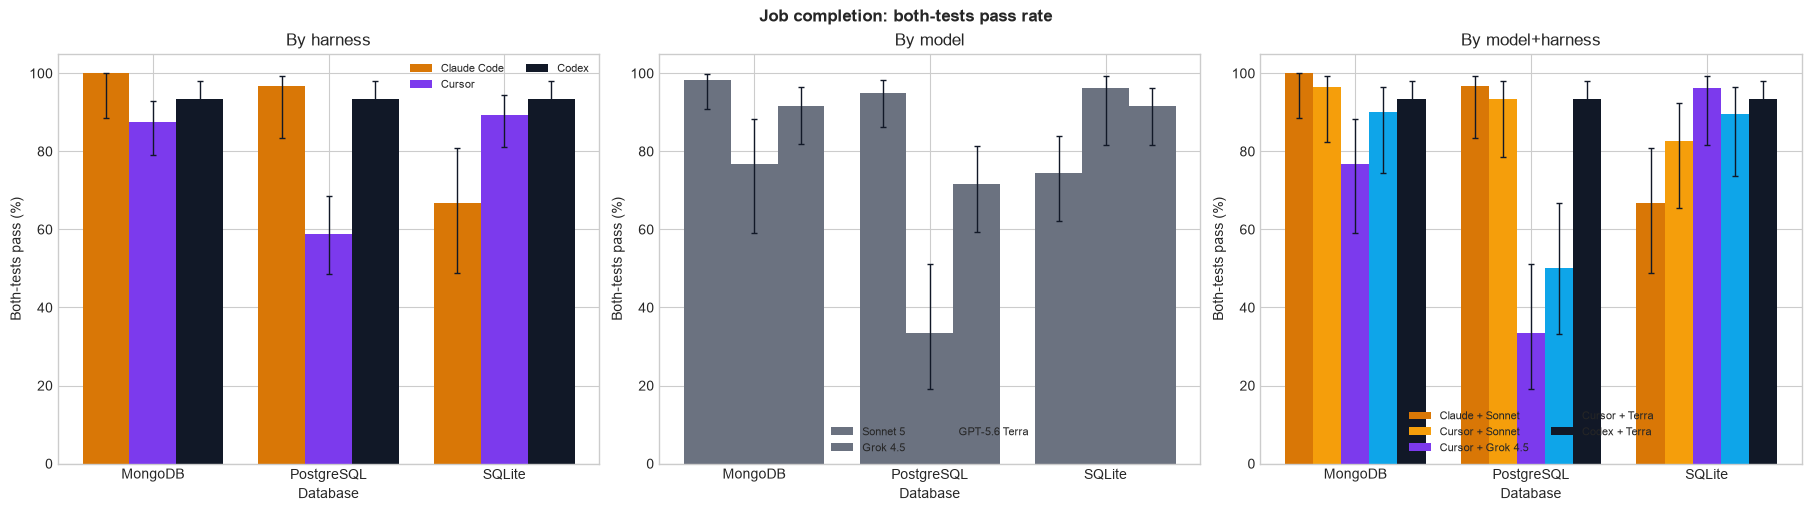

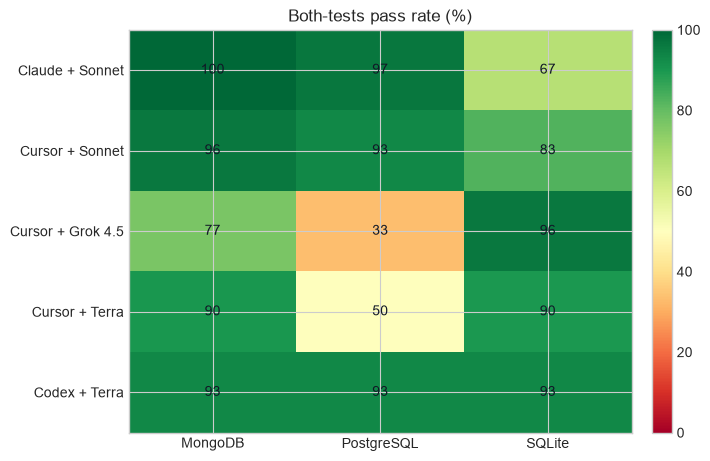

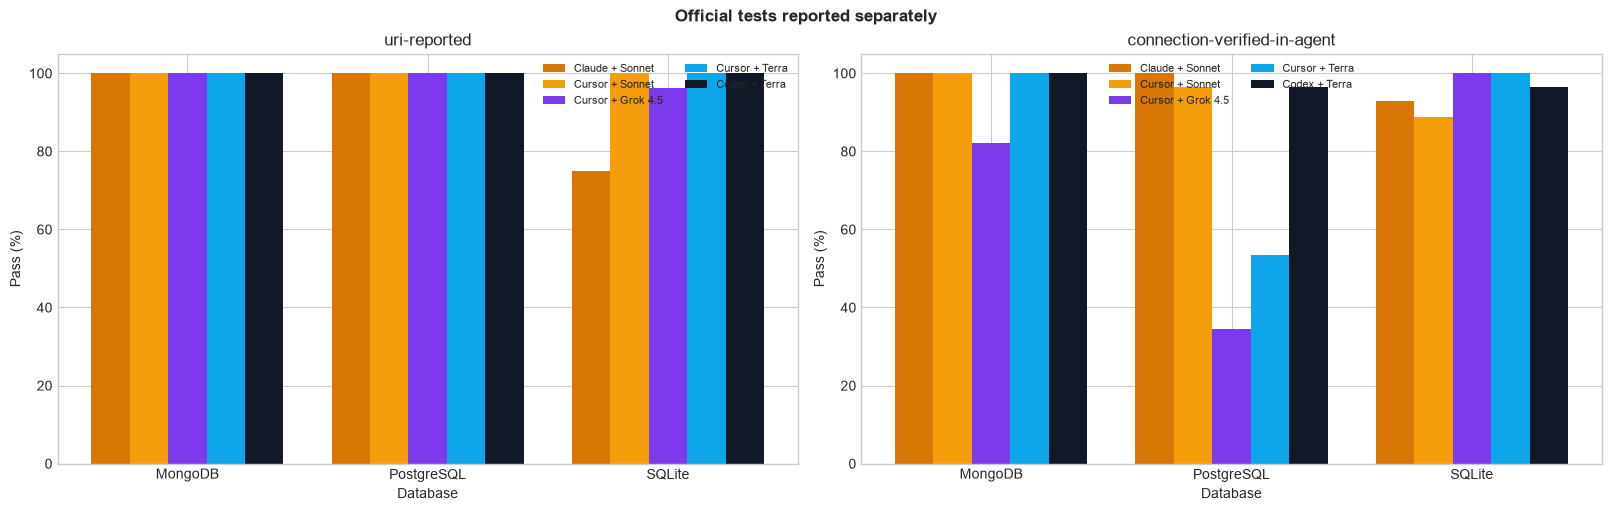

In [5]:
def rate_table(frame, group):
    table = (
        frame.groupby([group, "database"], observed=True)
        .agg(n=("run_id", "size"), passed=("both_tests_passed", "sum"))
        .reset_index()
    )
    intervals = [wilson_interval(row.passed, row.n) for row in table.itertuples()]
    table["pass_rate"] = [item[0] for item in intervals]
    table["pass_rate_lo"] = [item[1] for item in intervals]
    table["pass_rate_hi"] = [item[2] for item in intervals]
    table["pass_rate_pct"] = table["pass_rate"] * 100
    table["pass_rate_lo_pct"] = table["pass_rate_lo"] * 100
    table["pass_rate_hi_pct"] = table["pass_rate_hi"] * 100
    return table

if not READY:
    summary = pd.DataFrame()
    print("Waiting for measurements.")
else:
    by_harness = rate_table(runs, "harness")
    by_model = rate_table(runs, "model")
    by_extension = rate_table(runs, "extension")
    summary = (
        runs.groupby(["extension", "database"], observed=True)
        .agg(
            runs=("run_id", "size"),
            both_tests_passed=("both_tests_passed", "sum"),
            pass_rate=("both_tests_passed", "mean"),
            runtime_mean_s=("runtime_s", "mean"),
            turns_mean=("num_turns", "mean"),
            tool_calls_mean=("tool_calls_total", "mean"),
            cost_mean_usd=("cost_usd", "mean"),
            cost_total_usd=("cost_usd", "sum"),
        )
        .reset_index()
    )
    intervals = [
        wilson_interval(row.both_tests_passed, row.runs) for row in summary.itertuples()
    ]
    summary["pass_rate"] = [item[0] for item in intervals]
    summary["pass_rate_lo"] = [item[1] for item in intervals]
    summary["pass_rate_hi"] = [item[2] for item in intervals]
    summary["pass_rate_pct"] = summary["pass_rate"] * 100

    print("Completion by harness × database:")
    display(by_harness.round(3))
    print("Completion by model × database:")
    display(by_model.round(3))
    print("Completion by model+harness × database:")
    display(by_extension.round(3))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    grouped_bars(
        axes[0], by_harness, "harness", "pass_rate_pct", "By harness",
        "Both-tests pass (%)", percent=True, groups=HARNESS_ORDER,
        lo_column="pass_rate_lo_pct", hi_column="pass_rate_hi_pct",
    )
    grouped_bars(
        axes[1], by_model, "model", "pass_rate_pct", "By model",
        "Both-tests pass (%)", percent=True, groups=MODEL_ORDER,
        lo_column="pass_rate_lo_pct", hi_column="pass_rate_hi_pct",
    )
    grouped_bars(
        axes[2], by_extension, "extension", "pass_rate_pct", "By model+harness",
        "Both-tests pass (%)", percent=True,
        lo_column="pass_rate_lo_pct", hi_column="pass_rate_hi_pct",
    )
    fig.suptitle("Job completion: both-tests pass rate", fontweight="bold")
    plt.show()

    heat = (
        by_extension.pivot(index="extension", columns="database", values="pass_rate_pct")
        .reindex(index=[name for name in EXTENSION_ORDER if name in set(by_extension["extension"])])
        .reindex(columns=DATABASE_ORDER)
    )
    fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
    image = ax.imshow(heat.to_numpy(dtype=float), cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(heat.columns)), [label_of(name) for name in heat.columns])
    ax.set_yticks(range(len(heat.index)), [label_of(name) for name in heat.index])
    ax.set_title("Both-tests pass rate (%)")
    for row_index, extension in enumerate(heat.index):
        for col_index, database in enumerate(heat.columns):
            value = heat.iat[row_index, col_index]
            if pd.notna(value):
                ax.text(col_index, row_index, f"{value:.0f}", ha="center", va="center", color="#111827")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

    if not tests.empty:
        fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
        for ax, test_name, title in [
            (axes[0], "uri-reported", "uri-reported"),
            (axes[1], "connection-verified-in-agent", "connection-verified-in-agent"),
        ]:
            slice_ = test_summary[test_summary["test_name"] == test_name].copy()
            grouped_bars(ax, slice_, "extension", "rate_pct", title, "Pass (%)", percent=True)
        fig.suptitle("Official tests reported separately", fontweight="bold")
        plt.show()


## Job efficiency: runtime, cost, and turns

Technical design: agent runtime, cost, and **turns / tool use** by database ×
harness/model. Scope viz: completion time and cost per database by harness,
model, and model+harness.

Turns are plotted with the same slices. n=5 showed Codex often finishing in
1 turn while Cursor/Claude used more; scale should show whether that is a
stable efficiency signature.


Efficiency means by model+harness × database:


,extension,database,n,runtime_mean,runtime_median,cost_mean,cost_median,turns_mean,turns_median,tools_mean
0,claude-sonnet,mongodb,30,60.310,59.372,0.232,0.194,6.833,7.0,5.833
1,claude-sonnet,postgresql,30,58.324,42.122,0.203,0.258,5.500,5.0,4.500
2,claude-sonnet,sqlite,30,50.135,36.008,0.177,0.228,4.033,4.0,3.033
3,cursor-sonnet,mongodb,28,59.978,59.638,0.170,0.145,4.071,4.0,5.321
4,cursor-sonnet,postgresql,30,49.378,46.276,0.146,0.130,3.633,3.0,5.400
5,cursor-sonnet,sqlite,29,97.747,95.020,0.306,0.321,4.586,5.0,9.690
6,cursor-grok,mongodb,30,40.137,39.284,0.131,0.129,3.267,3.0,3.133
7,cursor-grok,postgresql,30,39.120,33.317,0.125,0.120,3.033,3.0,3.033
8,cursor-grok,sqlite,27,40.610,39.087,0.181,0.178,3.037,3.0,4.481
9,cursor-terra,mongodb,30,53.789,47.939,0.100,0.097,1.100,1.0,5.533


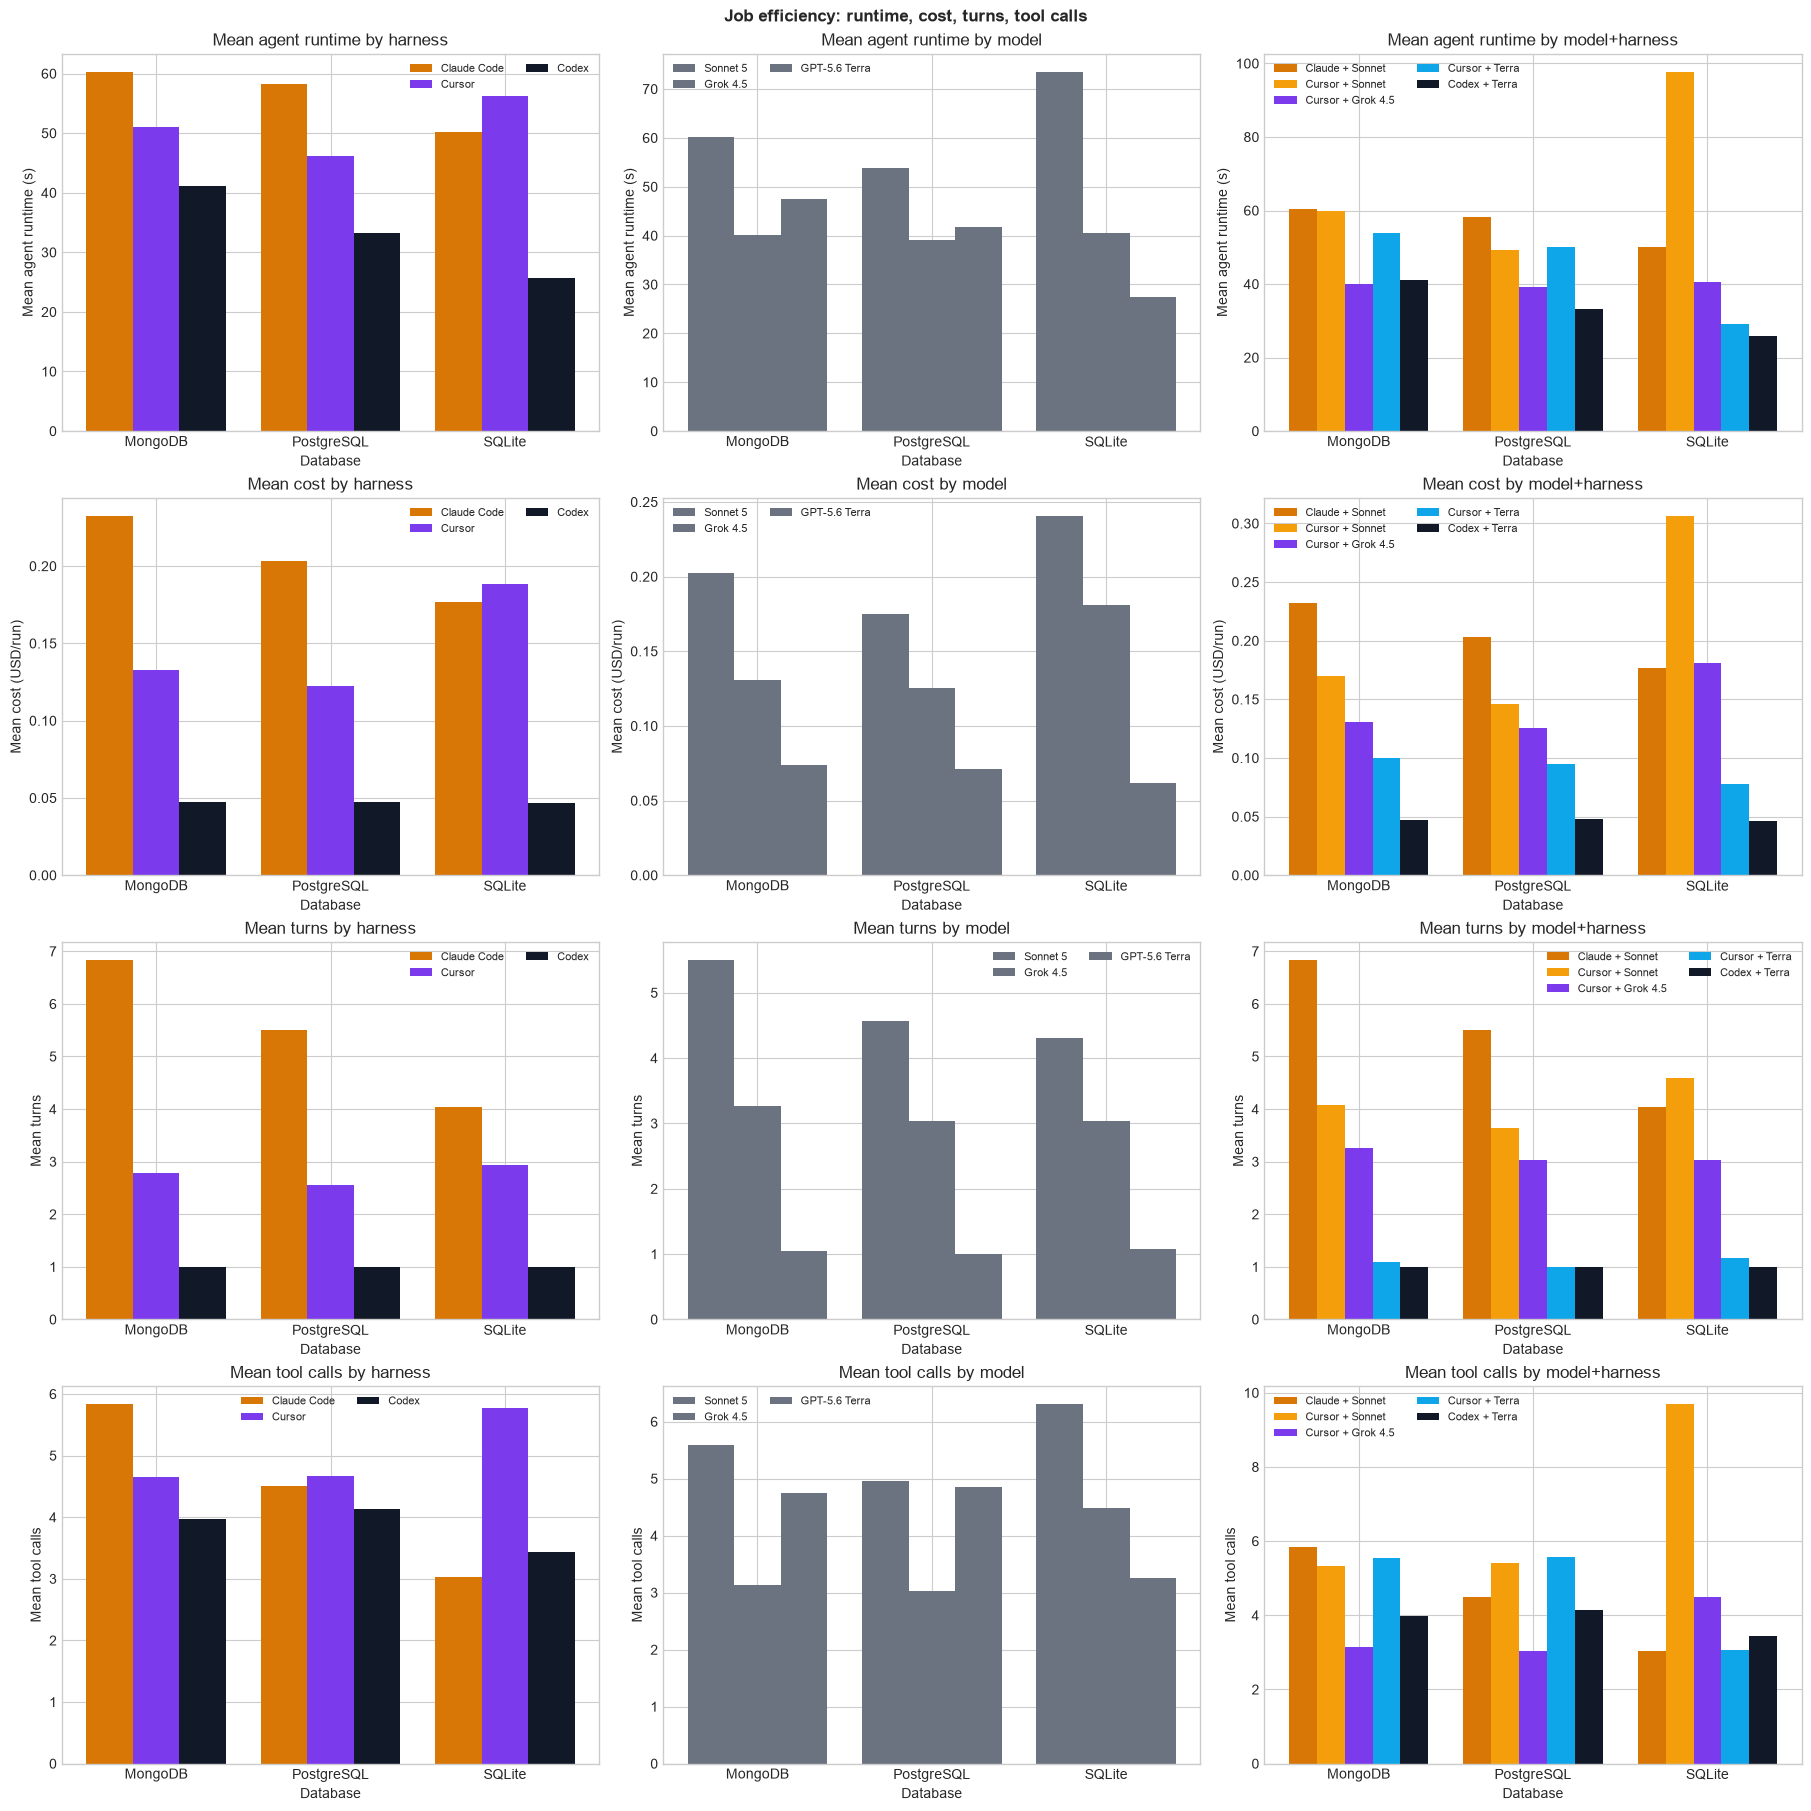

In [6]:
if not READY or summary.empty:
    print("Waiting for measurements.")
else:
    efficiency = (
        runs.groupby(["extension", "database"], observed=True)
        .agg(
            n=("run_id", "size"),
            runtime_mean=("runtime_s", "mean"),
            runtime_median=("runtime_s", "median"),
            cost_mean=("cost_usd", "mean"),
            cost_median=("cost_usd", "median"),
            turns_mean=("num_turns", "mean"),
            turns_median=("num_turns", "median"),
            tools_mean=("tool_calls_total", "mean"),
        )
        .reset_index()
    )
    print("Efficiency means by model+harness × database:")
    display(efficiency.round(3))

    by_h = (
        runs.groupby(["harness", "database"], observed=True)[
            ["runtime_s", "cost_usd", "num_turns", "tool_calls_total"]
        ]
        .mean()
        .reset_index()
        .rename(columns={"runtime_s": "runtime_mean", "cost_usd": "cost_mean", "num_turns": "turns_mean", "tool_calls_total": "tools_mean"})
    )
    by_m = (
        runs.groupby(["model", "database"], observed=True)[
            ["runtime_s", "cost_usd", "num_turns", "tool_calls_total"]
        ]
        .mean()
        .reset_index()
        .rename(columns={"runtime_s": "runtime_mean", "cost_usd": "cost_mean", "num_turns": "turns_mean", "tool_calls_total": "tools_mean"})
    )

    metrics = [
        ("runtime_mean", "Mean agent runtime (s)", False),
        ("cost_mean", "Mean cost (USD/run)", False),
        ("turns_mean", "Mean turns", False),
        ("tools_mean", "Mean tool calls", False),
    ]

    fig, axes = plt.subplots(4, 3, figsize=(18, 18), constrained_layout=True)
    slices = [
        (by_h, "harness", HARNESS_ORDER, "harness"),
        (by_m, "model", MODEL_ORDER, "model"),
        (efficiency.rename(columns={"runtime_mean": "runtime_mean", "cost_mean": "cost_mean", "turns_mean": "turns_mean", "tools_mean": "tools_mean"}), "extension", EXTENSION_ORDER, "model+harness"),
    ]
    # normalize efficiency column names already match
    for row, (metric, ylabel, percent) in enumerate(metrics):
        for col, (frame, group, groups, slice_name) in enumerate(slices):
            grouped_bars(
                axes[row, col],
                frame,
                group,
                metric,
                f"{ylabel.split('(')[0].strip()} by {slice_name}",
                ylabel,
                percent=percent,
                groups=groups,
            )
    fig.suptitle("Job efficiency: runtime, cost, turns, tool calls", fontweight="bold")
    plt.show()


## Turns in detail

n=5 hinted that turns separate cheap one-shot Codex paths from multi-turn
Cursor/Claude exploration. Scale distributions (not just means) show whether
that is a tight cluster or a long tail.


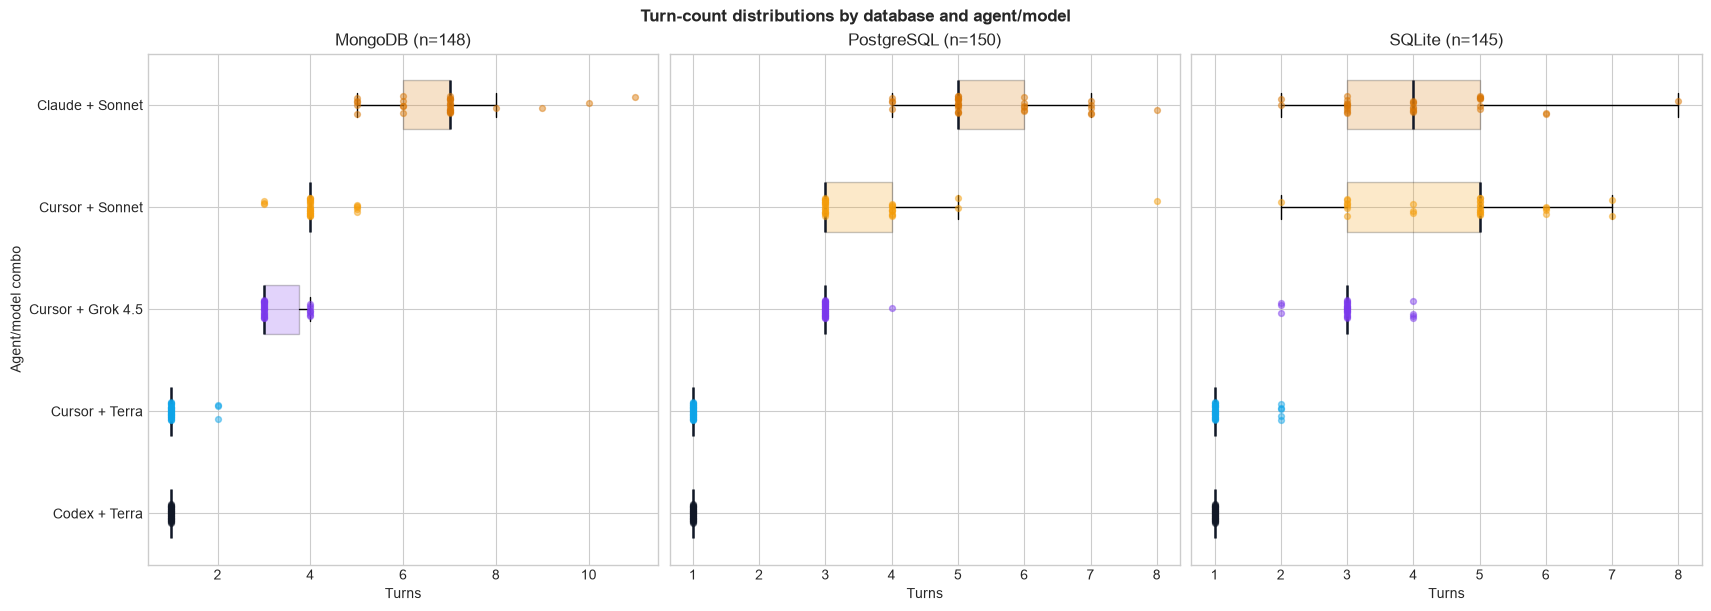

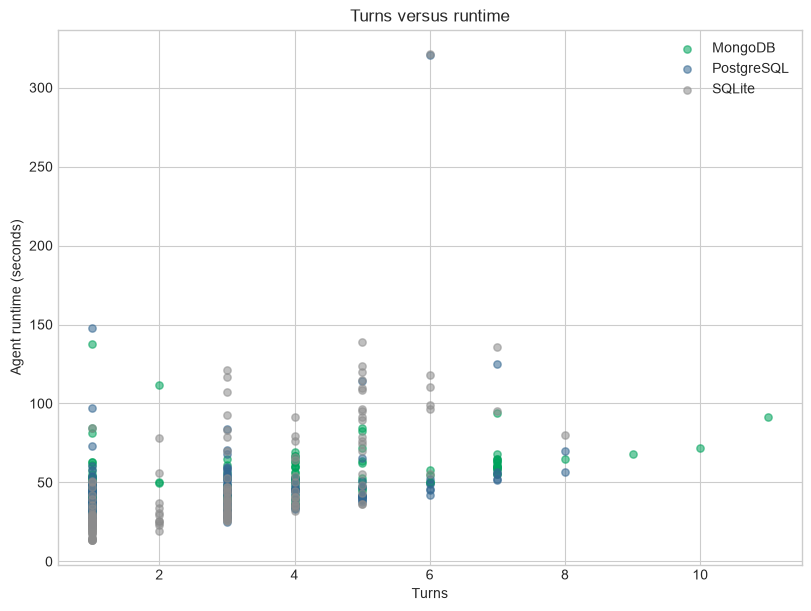

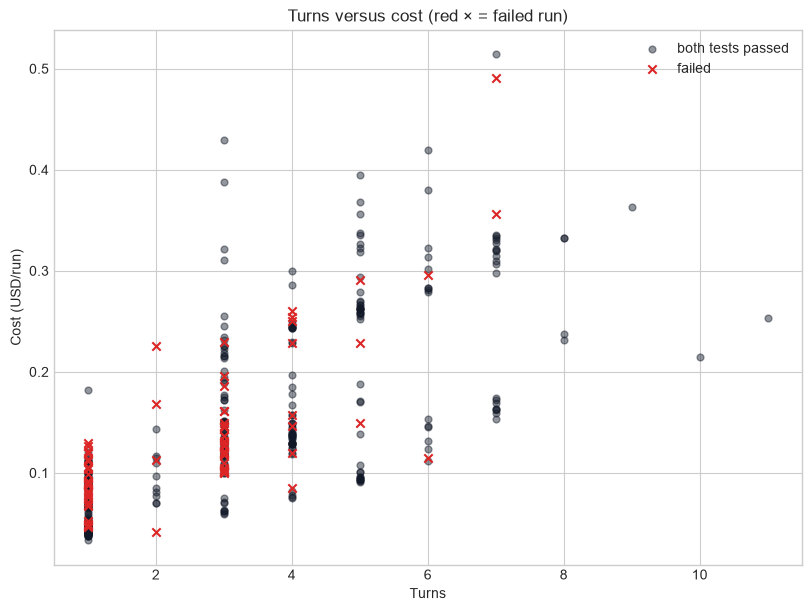

In [7]:
if not READY:
    print("Waiting for measurements.")
else:
    present_extensions = [name for name in EXTENSION_ORDER if name in set(runs["extension"])]
    extension_labels = [label_of(name) for name in present_extensions]
    y_positions = np.arange(len(present_extensions))

    fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        database_runs = runs[runs["database"] == database]
        distributions, positions = [], []
        for y_position, extension in zip(y_positions, present_extensions):
            values = (
                database_runs.loc[database_runs["extension"] == extension, "num_turns"]
                .dropna()
                .to_numpy(dtype=float)
            )
            if not len(values):
                continue
            distributions.append(values)
            positions.append(y_position)
            jitter = np.linspace(-0.09, 0.09, len(values)) if len(values) > 1 else np.array([0.0])
            ax.scatter(values, y_position + jitter, color=COLORS.get(extension, "#6B7280"), alpha=0.45, s=18, zorder=3)
        if distributions:
            boxes = ax.boxplot(
                distributions,
                positions=positions,
                orientation="horizontal",
                widths=0.48,
                patch_artist=True,
                showfliers=False,
                medianprops={"color": "#111827", "linewidth": 1.8},
            )
            for patch, position in zip(boxes["boxes"], positions):
                patch.set_facecolor(COLORS.get(present_extensions[position], "#9CA3AF"))
                patch.set_alpha(0.22)
        ax.set_title(f"{label_of(database)} (n={len(database_runs)})")
        ax.set_xlabel("Turns")
        ax.set_yticks(y_positions, extension_labels)
        ax.invert_yaxis()
    axes[0].set_ylabel("Agent/model combo")
    fig.suptitle("Turn-count distributions by database and agent/model", fontweight="bold")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    for database in DATABASE_ORDER:
        subset = runs[runs["database"] == database]
        ax.scatter(
            subset["num_turns"],
            subset["runtime_s"],
            label=label_of(database),
            color=COLORS[database],
            alpha=0.55,
            s=28,
        )
    ax.set_xlabel("Turns")
    ax.set_ylabel("Agent runtime (seconds)")
    ax.set_title("Turns versus runtime")
    ax.legend(frameon=False)
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
    passed = runs["both_tests_passed"].to_numpy(dtype=bool)
    ax.scatter(runs.loc[passed, "num_turns"], runs.loc[passed, "cost_usd"], color="#111827", alpha=0.45, s=24, label="both tests passed")
    ax.scatter(runs.loc[~passed, "num_turns"], runs.loc[~passed, "cost_usd"], color="#DC2626", marker="x", s=36, label="failed")
    ax.set_xlabel("Turns")
    ax.set_ylabel("Cost (USD/run)")
    ax.set_title("Turns versus cost (red × = failed run)")
    ax.legend(frameon=False)
    plt.show()


## Compound completion and efficiency: Pareto frontier

Technical design / scope: one series per database; x-axis cost **or** time
(choose from the data); y-axis successful-provision rate. This notebook plots
**both** cost and time, plus turns, so the choice is visible rather than
pre-committed.

Each point is one model+harness cell. Lines connect cells within a database,
sorted by the x-axis. If completion is near-ceiling for a database, the
frontier collapses and the efficiency boxplots above are the better view.


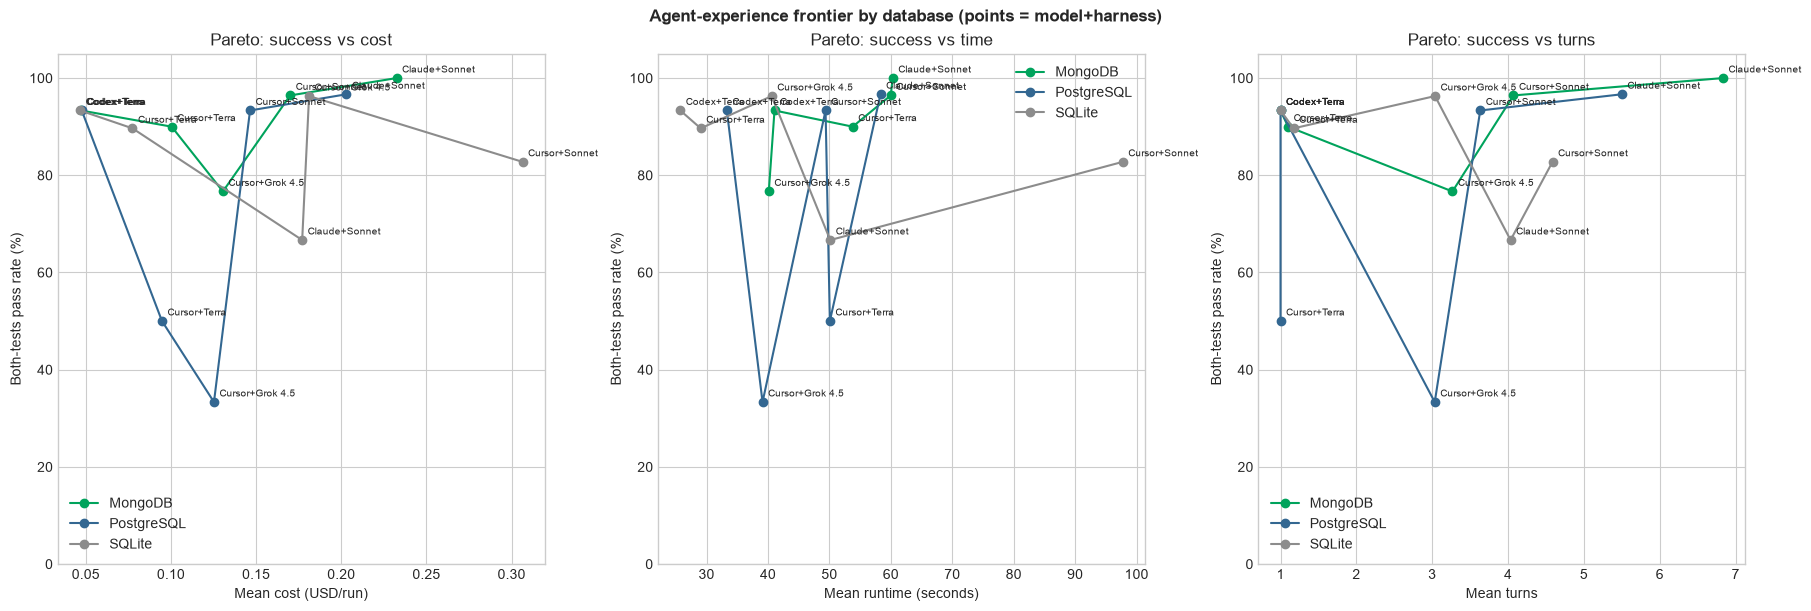

In [8]:
if not READY or summary.empty:
    print("Waiting for measurements.")
else:
    def pareto(ax, x_column, xlabel, title):
        for database in DATABASE_ORDER:
            subset = summary[summary["database"] == database].sort_values(x_column)
            ax.plot(
                subset[x_column],
                subset["pass_rate_pct"],
                marker="o",
                color=COLORS[database],
                label=label_of(database),
            )
            for _, row in subset.iterrows():
                ax.annotate(
                    label_of(row["extension"]).replace(" + ", "+"),
                    (row[x_column], row["pass_rate_pct"]),
                    fontsize=7,
                    xytext=(4, 4),
                    textcoords="offset points",
                )
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Both-tests pass rate (%)")
        ax.set_ylim(0, 105)
        ax.set_title(title)
        ax.legend(frameon=False)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
    pareto(axes[0], "cost_mean_usd", "Mean cost (USD/run)", "Pareto: success vs cost")
    pareto(axes[1], "runtime_mean_s", "Mean runtime (seconds)", "Pareto: success vs time")
    pareto(axes[2], "turns_mean", "Mean turns", "Pareto: success vs turns")
    fig.suptitle("Agent-experience frontier by database (points = model+harness)", fontweight="bold")
    plt.show()


## Provisioning methods

Technical design RQ2: classify with the versioned codebook. `final_method` is
the **last attempted method**, even when tests fail. Do not overwrite that
with `none`.

Outcome is a separate field:

- `verified` — both official tests passed
- `unverified` — tests ran and at least one failed (readiness-only, URI miss, …)
- `unscored` — agent finished but `test_output` was never recorded

Requested views:

1. **Each agent/model × database** — inferred final method per combo
2. **All agent/models × database** — pooled method mix, and method counts
   with method on the x-axis (scope viz)


,extension,database,repeat_idx,attempted_path,final_method,method_outcome,both_tests_passed
0,claude-sonnet,mongodb,0,container,container,verified,True
1,claude-sonnet,mongodb,1,container,container,verified,True
2,claude-sonnet,mongodb,2,container,container,verified,True
3,claude-sonnet,mongodb,3,container,container,verified,True
4,claude-sonnet,mongodb,4,container,container,verified,True
...,...,...,...,...,...,...,...
175,codex-terra,sqlite,25,built-in-library,built-in-library,verified,True
176,codex-terra,sqlite,26,built-in-library,built-in-library,verified,True
177,codex-terra,sqlite,27,built-in-library,built-in-library,verified,True
178,codex-terra,sqlite,28,built-in-library,built-in-library,verified,True


Attempted method counts (a fallback run may appear more than once):


,database,attempted_methods,runs
0,mongodb,container,148
1,postgresql,container,149
2,postgresql,os-package-manager,2
3,sqlite,built-in-library,123
4,sqlite,container,24
5,sqlite,language-package-runtime,4
6,sqlite,official-binary-archive,2
7,sqlite,os-package-manager,9
8,sqlite,preinstalled-runtime,1


Inferred final method counts:


,database,final_method,runs
0,mongodb,container,148
1,postgresql,container,149
2,postgresql,os-package-manager,1
3,sqlite,built-in-library,115
4,sqlite,container,22
5,sqlite,language-package-runtime,4
6,sqlite,official-binary-archive,1
7,sqlite,os-package-manager,2
8,sqlite,preinstalled-runtime,1


Method outcome (tests vs last attempted method):


method_outcome                       verified  unverified  unscored
database   final_method                                            
mongodb    container                      135           5         8
postgresql container                      109          34         6
           os-package-manager               1           0         0
sqlite     built-in-library               101           9         5
           container                       17           3         2
           language-package-runtime         3           0         1
           official-binary-archive          1           0         0
           os-package-manager               2           0         0
           preinstalled-runtime             0           1         0

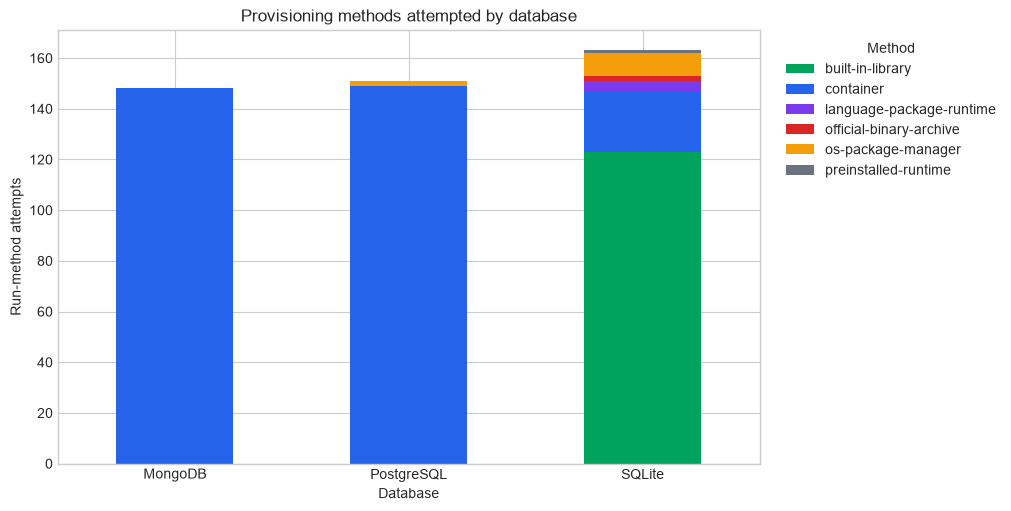

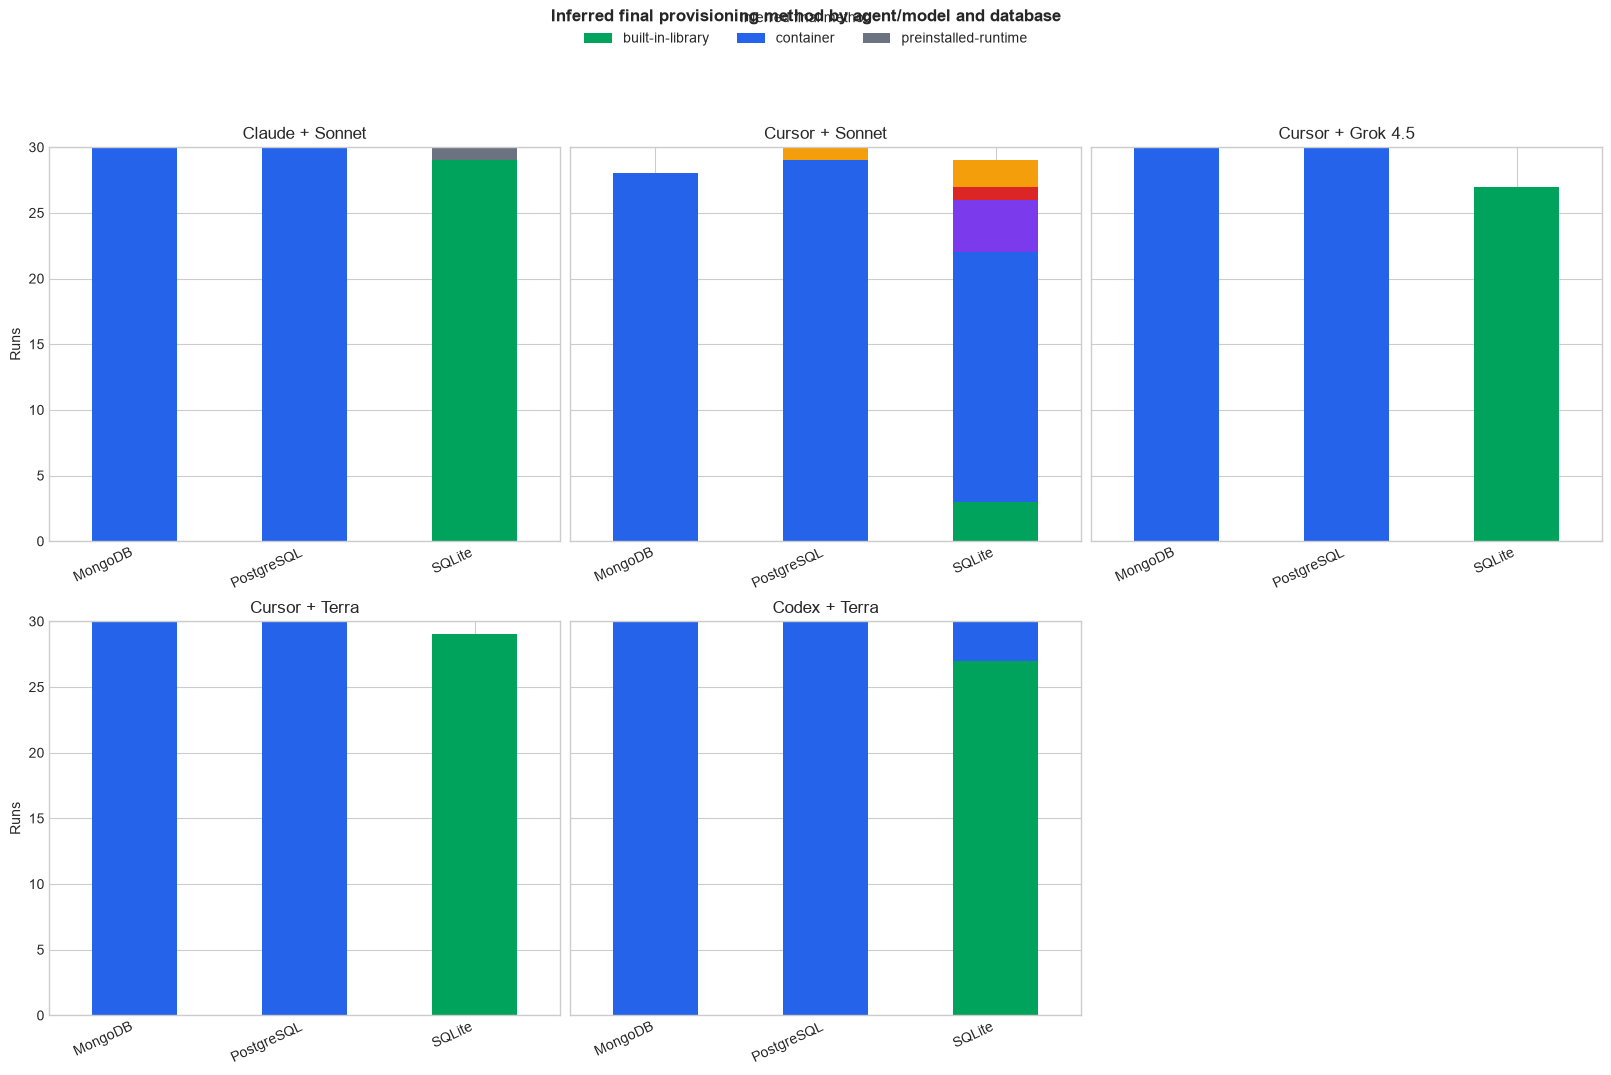

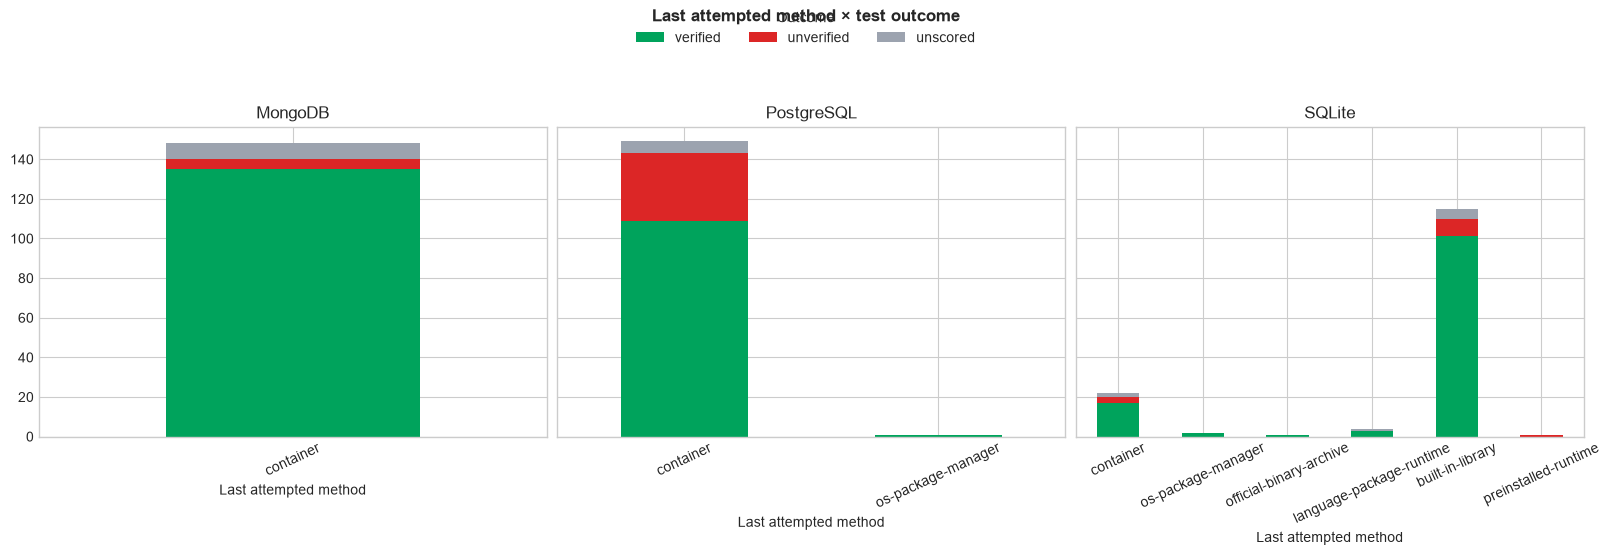

In [9]:
if not READY:
    method_runs = pd.DataFrame()
    print("Waiting for measurements.")
else:
    method_sql = f"""
    SELECT
        run_id,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            positionCaseInsensitive(payload, 'docker run') > 0
            OR positionCaseInsensitive(payload, 'podman run') > 0
        ) AS container_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                positionCaseInsensitive(payload, 'apt-get install') > 0
                OR positionCaseInsensitive(payload, 'apt install') > 0
                OR positionCaseInsensitive(payload, 'dnf install') > 0
                OR positionCaseInsensitive(payload, 'yum install') > 0
                OR positionCaseInsensitive(payload, 'apk add') > 0
                OR positionCaseInsensitive(payload, 'brew install') > 0
            )
            AND positionCaseInsensitive(payload, 'docker') = 0
            AND (
                (prompt_id = 'mongodb' AND positionCaseInsensitive(payload, 'mongo') > 0)
                OR (prompt_id = 'postgresql' AND positionCaseInsensitive(payload, 'postgres') > 0)
                OR (prompt_id = 'sqlite' AND positionCaseInsensitive(payload, 'sqlite') > 0)
            )
        ) AS os_package_manager_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                positionCaseInsensitive(payload, 'curl ') > 0
                OR positionCaseInsensitive(payload, 'wget ') > 0
            )
            AND (
                positionCaseInsensitive(payload, '.tgz') > 0
                OR positionCaseInsensitive(payload, '.tar.gz') > 0
                OR positionCaseInsensitive(payload, '.zip') > 0
            )
            AND (
                (prompt_id = 'mongodb' AND positionCaseInsensitive(payload, 'mongo') > 0)
                OR (prompt_id = 'postgresql' AND positionCaseInsensitive(payload, 'postgres') > 0)
                OR (prompt_id = 'sqlite' AND positionCaseInsensitive(payload, 'sqlite') > 0)
            )
        ) AS official_binary_archive_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                positionCaseInsensitive(payload, 'pip install') > 0
                OR positionCaseInsensitive(payload, 'pip3 install') > 0
                OR positionCaseInsensitive(payload, 'npm install') > 0
                OR positionCaseInsensitive(payload, 'npm add') > 0
            )
            AND (
                (prompt_id = 'mongodb' AND positionCaseInsensitive(payload, 'mongo') > 0)
                OR (prompt_id = 'postgresql' AND positionCaseInsensitive(payload, 'postgres') > 0)
                OR (prompt_id = 'sqlite' AND (
                    positionCaseInsensitive(payload, 'sqlite') > 0
                    OR positionCaseInsensitive(payload, 'libsql') > 0
                    OR positionCaseInsensitive(payload, 'sqld') > 0
                ))
            )
        ) AS language_package_runtime_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            prompt_id = 'sqlite'
            AND (
                positionCaseInsensitive(payload, 'import sqlite3') > 0
                OR positionCaseInsensitive(payload, 'from sqlite3') > 0
            )
        ) AS built_in_library_seq,
        maxIf(toUInt64(coalesce(source_seq, 0)),
            (
                (prompt_id = 'mongodb' AND (
                    positionCaseInsensitive(payload, ' mongod ') > 0
                    OR positionCaseInsensitive(payload, 'systemctl start mongod') > 0
                ))
                OR (prompt_id = 'postgresql' AND (
                    positionCaseInsensitive(payload, 'pg_ctl') > 0
                    OR positionCaseInsensitive(payload, 'systemctl start postgres') > 0
                ))
                OR (prompt_id = 'sqlite' AND positionCaseInsensitive(payload, 'sqlite3 ') > 0)
            )
        ) AS preinstalled_runtime_seq
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
      AND coalesce(assertion_role, 'primary') = 'primary'
    GROUP BY run_id
    """
    method_evidence = ax_query(method_sql)
    sequence_columns = {
        "container": "container_seq",
        "os-package-manager": "os_package_manager_seq",
        "official-binary-archive": "official_binary_archive_seq",
        "language-package-runtime": "language_package_runtime_seq",
        "built-in-library": "built_in_library_seq",
        "preinstalled-runtime": "preinstalled_runtime_seq",
    }
    if method_evidence.empty:
        method_evidence = pd.DataFrame(columns=["run_id", *sequence_columns.values()])
    for column in sequence_columns.values():
        if column not in method_evidence.columns:
            method_evidence[column] = 0
        method_evidence[column] = pd.to_numeric(method_evidence[column], errors="coerce").fillna(0)

    method_runs = runs.merge(method_evidence, on="run_id", how="left")
    for column in sequence_columns.values():
        method_runs[column] = pd.to_numeric(method_runs[column], errors="coerce").fillna(0)

    def _seq(row, column):
        value = row.get(column, 0)
        if value is None or (isinstance(value, float) and np.isnan(value)) or pd.isna(value):
            return 0
        return int(value)

    def classify_methods(row):
        ordered = [
            (method, _seq(row, column))
            for method, column in sequence_columns.items()
            if _seq(row, column) > 0
        ]
        acquisition_methods = {
            "container",
            "os-package-manager",
            "official-binary-archive",
            "language-package-runtime",
            "built-in-library",
        }
        # Starting software installed by apt/npm is part of that install path,
        # not a separate preinstalled-runtime method.
        if any(method in acquisition_methods for method, _ in ordered):
            ordered = [item for item in ordered if item[0] != "preinstalled-runtime"]
        ordered.sort(key=lambda item: item[1])
        attempted = [method for method, _ in ordered] or ["unknown"]
        passed = bool(row.get("both_tests_passed") is True or row.get("both_tests_passed") == 1)
        n_test_results = int(row.get("test_pass_count") or 0) + int(row.get("test_fail_count") or 0)
        if passed:
            outcome = "verified"
        elif n_test_results > 0:
            outcome = "unverified"
        else:
            outcome = "unscored"
        return attempted, attempted[-1], outcome

    classified = method_runs.apply(classify_methods, axis=1)
    method_runs["attempted_methods"] = [item[0] for item in classified]
    method_runs["final_method"] = [item[1] for item in classified]
    method_runs["method_outcome"] = [item[2] for item in classified]
    method_runs["attempted_path"] = method_runs["attempted_methods"].str.join(" → ")

    method_display = method_runs[
        ["extension", "database", "repeat_idx", "attempted_path", "final_method", "method_outcome", "both_tests_passed"]
    ].sort_values(["database", "extension", "repeat_idx"])
    display(method_display)

    attempted = method_runs[["run_id", "database", "extension", "attempted_methods"]].explode("attempted_methods")
    attempted_counts = (
        attempted.groupby(["database", "attempted_methods"], observed=True)
        .size()
        .rename("runs")
        .reset_index()
    )
    final_counts = (
        method_runs.groupby(["database", "final_method"], observed=True)
        .size()
        .rename("runs")
        .reset_index()
    )
    print("Attempted method counts (a fallback run may appear more than once):")
    display(attempted_counts)
    print("Inferred final method counts:")
    display(final_counts)
    print("Method outcome (tests vs last attempted method):")
    display(
        pd.crosstab(
            [method_runs["database"], method_runs["final_method"]],
            method_runs["method_outcome"],
        )
        .reindex(columns=OUTCOME_ORDER, fill_value=0)
    )

    method_colors = METHOD_COLORS

    attempted_pivot = attempted_counts.pivot(
        index="database", columns="attempted_methods", values="runs"
    ).fillna(0).reindex(DATABASE_ORDER)
    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    attempted_pivot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[method_colors.get(column, "#9CA3AF") for column in attempted_pivot.columns],
    )
    ax.set_title("Provisioning methods attempted by database")
    ax.set_xlabel("Database")
    ax.set_ylabel("Run-method attempts")
    ax.set_xticklabels([DISPLAY_NAMES[name] for name in DATABASE_ORDER], rotation=0)
    ax.legend(title="Method", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.show()

    present_extensions = [name for name in EXTENSION_ORDER if name in set(method_runs["extension"])]
    n_ext = max(len(present_extensions), 1)
    nrows = 2 if n_ext > 3 else 1
    ncols = 3 if n_ext > 1 else 1
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5 * nrows), sharey=True, constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, extension in zip(axes.flat, present_extensions):
        subset = method_runs[method_runs["extension"] == extension]
        pivot = pd.crosstab(subset["database"], subset["final_method"]).reindex(DATABASE_ORDER, fill_value=0)
        pivot.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            color=[method_colors.get(column, "#9CA3AF") for column in pivot.columns],
            legend=False,
        )
        ax.set_title(DISPLAY_NAMES.get(extension, extension))
        ax.set_xlabel("")
        ax.set_ylabel("Runs")
        ax.set_xticklabels([DISPLAY_NAMES[name] for name in DATABASE_ORDER], rotation=25, ha="right")
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Inferred final method", loc="outside upper center", ncol=4, frameon=False)
    for ax in axes[len(present_extensions):]:
        ax.set_visible(False)
    fig.suptitle("Inferred final provisioning method by agent/model and database", y=1.06, fontweight="bold")
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        subset = method_runs[method_runs["database"] == database]
        pivot = (
            pd.crosstab(subset["final_method"], subset["method_outcome"])
            .reindex(
                [name for name in METHOD_ORDER if name in set(subset["final_method"])],
                fill_value=0,
            )
            .reindex(columns=OUTCOME_ORDER, fill_value=0)
        )
        pivot.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            color=[OUTCOME_COLORS[name] for name in pivot.columns],
            legend=False,
        )
        ax.set_title(label_of(database))
        ax.set_xlabel("Last attempted method")
        ax.tick_params(axis="x", rotation=25)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Outcome", loc="outside upper center", ncol=3, frameon=False)
    fig.suptitle("Last attempted method × test outcome", y=1.08, fontweight="bold")
    plt.show()


## Provisioning method by each agent/model × database

Same codebook labels, different cut: one panel per database, x-axis is the
pinned agent/model combo. This is the scale-run answer to "what method did
each combo actually use?"


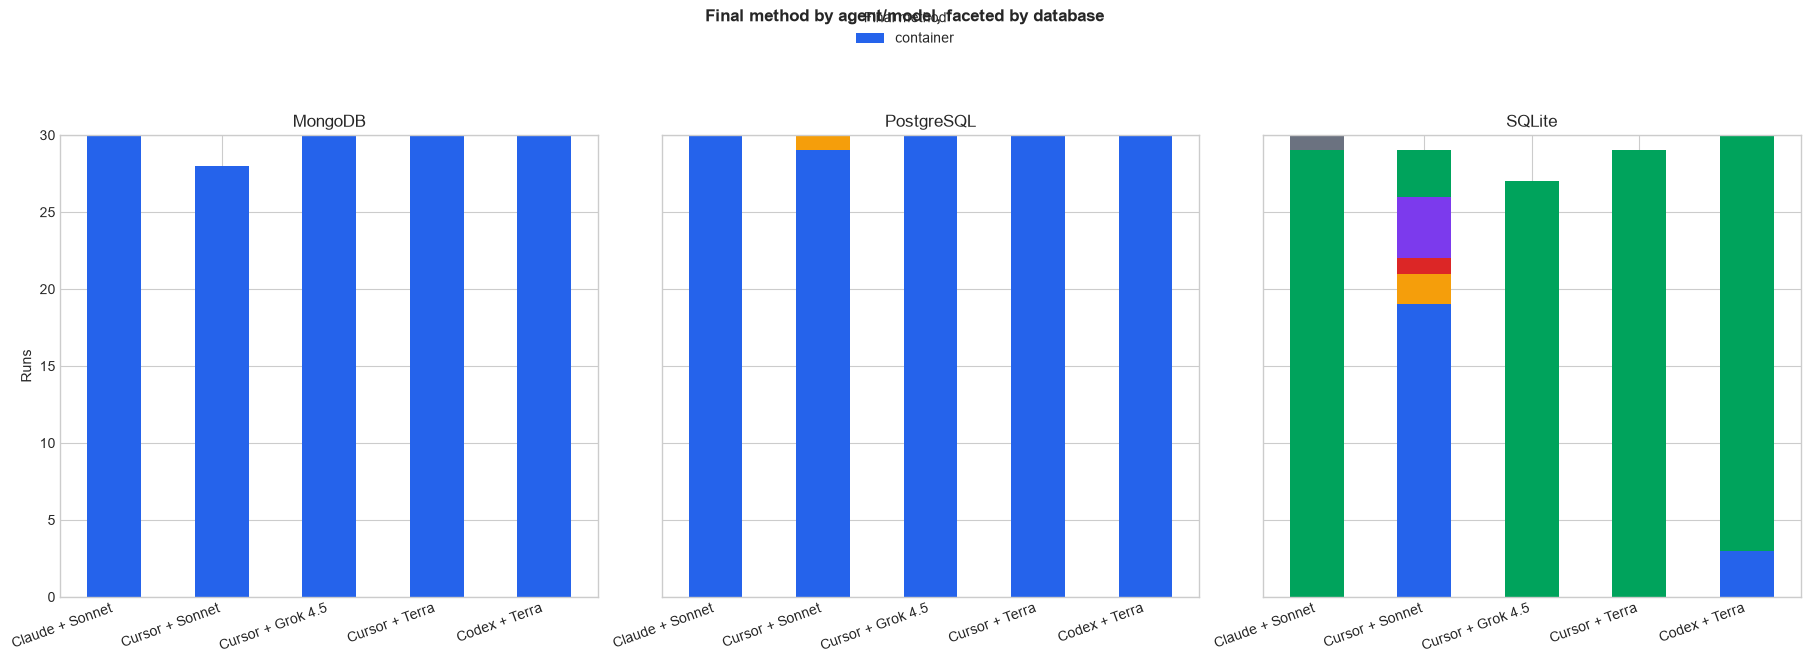

Final method counts by agent/model × database:


final_method              container  os-package-manager  \
extension     database                                    
claude-sonnet mongodb            30                   0   
              postgresql         30                   0   
              sqlite              0                   0   
cursor-sonnet mongodb            28                   0   
              postgresql         29                   1   
              sqlite             19                   2   
cursor-grok   mongodb            30                   0   
              postgresql         30                   0   
              sqlite              0                   0   
cursor-terra  mongodb            30                   0   
              postgresql         30                   0   
              sqlite              0                   0   
codex-terra   mongodb            30                   0   
              postgresql         30                   0   
              sqlite              3                   0   

final_method              official-binary-archive  language-package-runtime  \
extension     database                                                        
claude-sonnet mongodb                           0                         0   
              postgresql                        0                         0   
              sqlite                            0                         0   
cursor-sonnet mongodb                           0                         0   
              postgresql                        0                         0   
              sqlite                            1                         4   
cursor-grok   mongodb                           0                         0   
              postgresql                        0                         0   
              sqlite                            0                         0   
cursor-terra  mongodb                           0                         0   
              postgresql                        0                         0   
              sqlite                            0                         0   
codex-terra   mongodb                           0                         0   
              postgresql                        0                         0   
              sqlite                            0                         0   

final_method              built-in-library  preinstalled-runtime  
extension     database                                            
claude-sonnet mongodb                    0                     0  
              postgresql                 0                     0  
              sqlite                    29                     1  
cursor-sonnet mongodb                    0                     0  
              postgresql                 0                     0  
              sqlite                     3                     0  
cursor-grok   mongodb                    0                     0  
              postgresql                 0                     0  
              sqlite                    27                     0  
cursor-terra  mongodb                    0                     0  
              postgresql                 0                     0  
              sqlite                    29                     0  
codex-terra   mongodb                    0                     0  
              postgresql                 0                     0  
              sqlite                    27                     0

In [10]:
if not READY or "method_runs" not in globals() or method_runs.empty:
    print("Waiting for method classification.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        stacked_method_bars(
            ax,
            method_runs[method_runs["database"] == database],
            "extension",
            EXTENSION_ORDER,
            label_of(database),
        )
        ax.set_ylabel("Runs")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Final method", loc="outside upper center", ncol=4, frameon=False)
    fig.suptitle("Final method by agent/model, faceted by database", y=1.08, fontweight="bold")
    plt.show()

    print("Final method counts by agent/model × database:")
    display(
        pd.crosstab(
            [method_runs["extension"], method_runs["database"]],
            method_runs["final_method"],
        )
        .reindex(columns=[name for name in METHOD_ORDER if name in set(method_runs["final_method"])], fill_value=0)
    )


## Provisioning method by harness and by model

Scope viz: method mix per database sliced by harness and by model, not only
by the pinned model+harness extension.


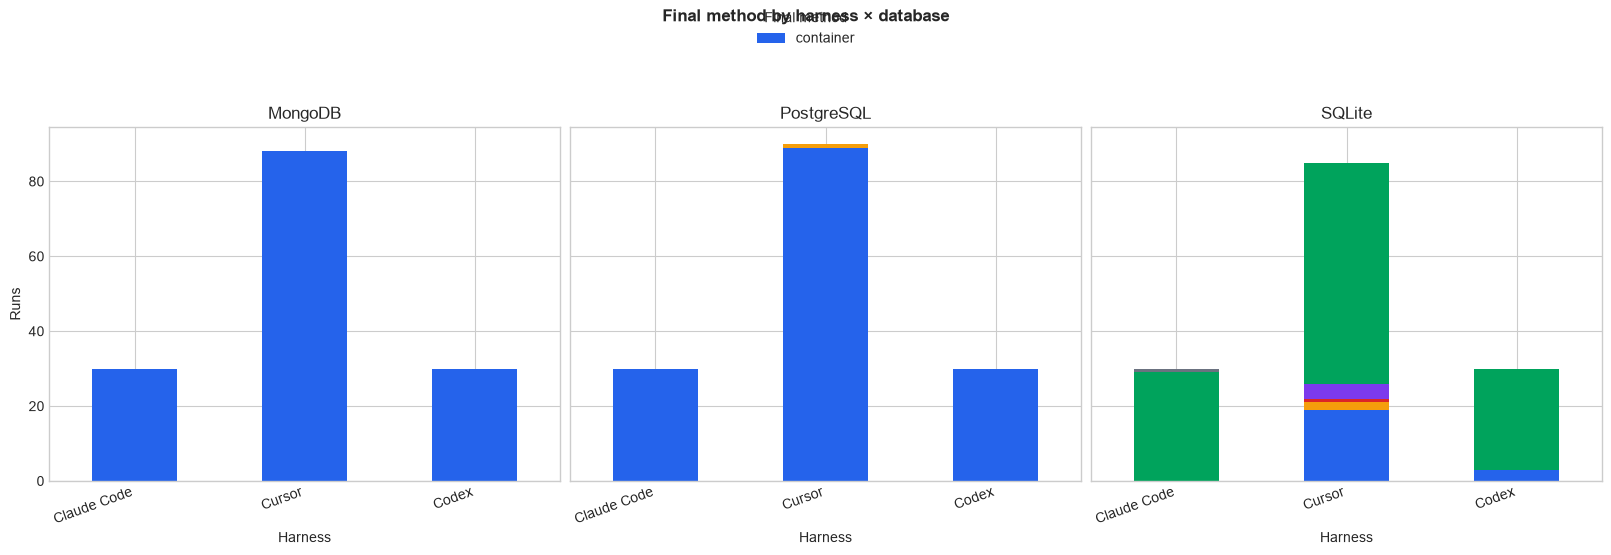

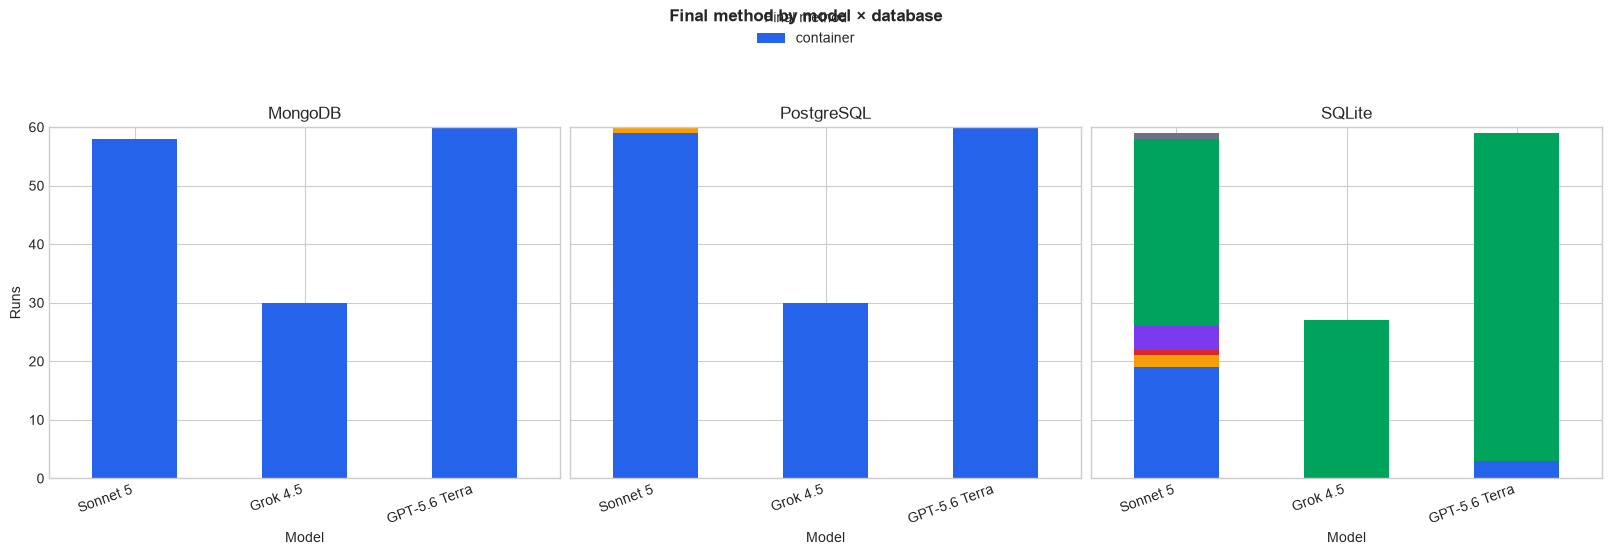

In [11]:
if not READY or "method_runs" not in globals() or method_runs.empty:
    print("Waiting for method classification.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        stacked_method_bars(
            ax,
            method_runs[method_runs["database"] == database],
            "harness",
            HARNESS_ORDER,
            label_of(database),
        )
        ax.set_xlabel("Harness")
        ax.set_ylabel("Runs")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Final method", loc="outside upper center", ncol=4, frameon=False)
    fig.suptitle("Final method by harness × database", y=1.08, fontweight="bold")
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        stacked_method_bars(
            ax,
            method_runs[method_runs["database"] == database],
            "model",
            MODEL_ORDER,
            label_of(database),
        )
        ax.set_xlabel("Model")
        ax.set_ylabel("Runs")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Final method", loc="outside upper center", ncol=4, frameon=False)
    fig.suptitle("Final method by model × database", y=1.08, fontweight="bold")
    plt.show()


## Provisioning method: pooled across all agent/models

X-axis is the codebook method; y-axis is run count. Facet by database, then
one pooled bar across databases (scope viz: method across DBs).


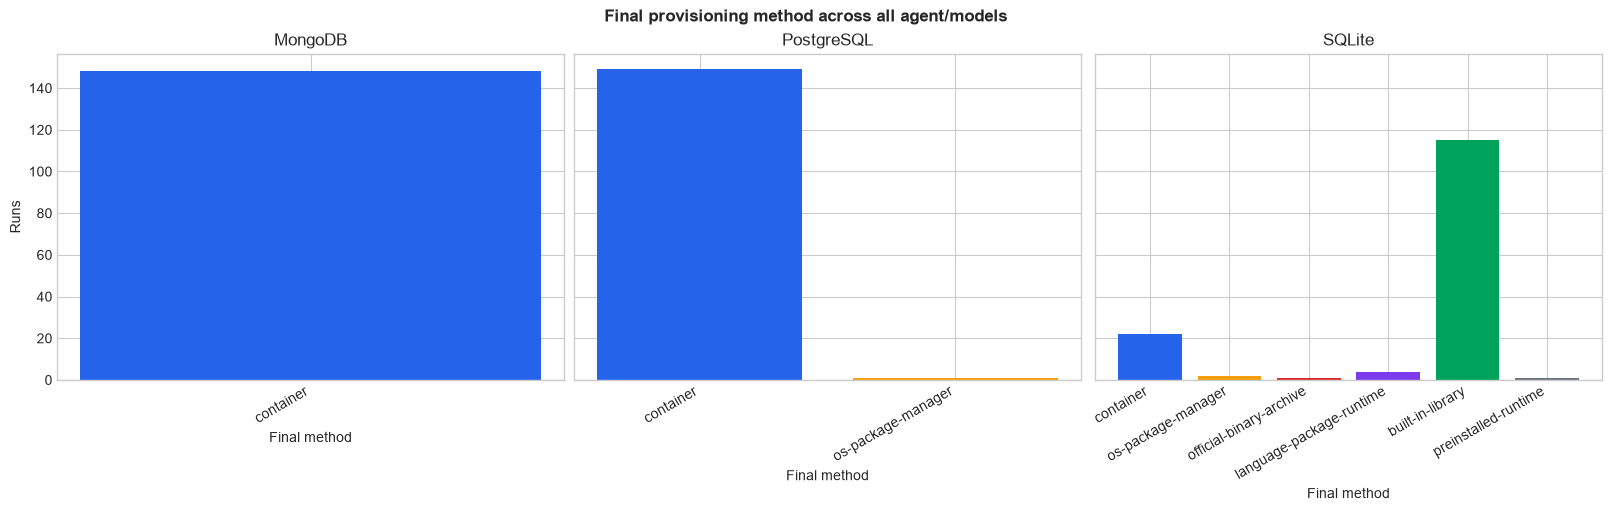

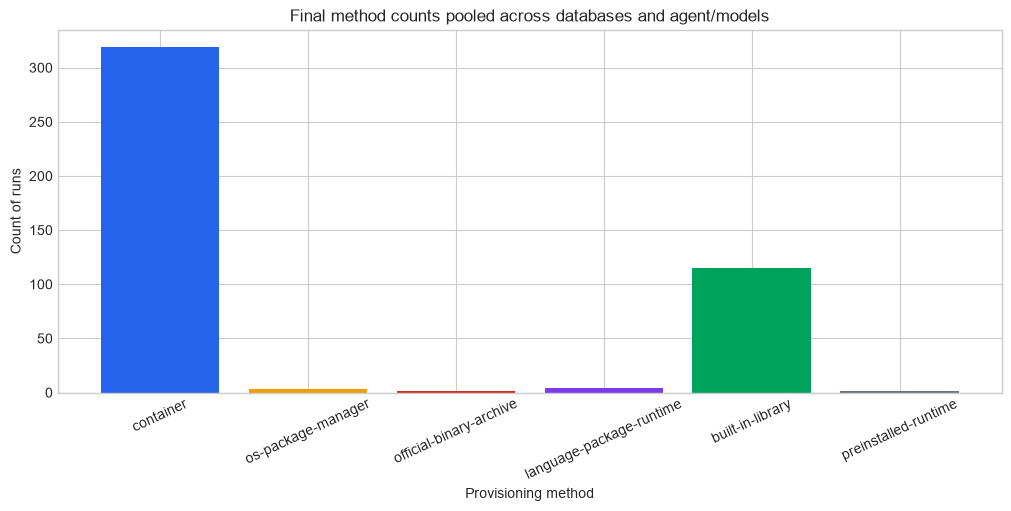

Attempted-path sequences (top 20):


,database,extension,attempted_path,runs
0,mongodb,claude-sonnet,container,30
2,mongodb,cursor-grok,container,30
3,mongodb,cursor-terra,container,30
4,mongodb,codex-terra,container,30
5,postgresql,claude-sonnet,container,30
9,postgresql,cursor-grok,container,30
10,postgresql,cursor-terra,container,30
11,postgresql,codex-terra,container,30
25,sqlite,cursor-terra,built-in-library,29
12,sqlite,claude-sonnet,built-in-library,29


In [12]:
if not READY or "method_runs" not in globals() or method_runs.empty:
    print("Waiting for method classification.")
else:
    method_order = [name for name in METHOD_ORDER if name in set(method_runs["final_method"])]
    final_by_db = (
        method_runs.groupby(["database", "final_method"], observed=True)
        .size()
        .rename("runs")
        .reset_index()
    )
    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True, constrained_layout=True)
    for ax, database in zip(axes, DATABASE_ORDER):
        subset = final_by_db[final_by_db["database"] == database]
        methods = [name for name in method_order if name in set(subset["final_method"])]
        counts = [
            int(subset.loc[subset["final_method"] == name, "runs"].sum()) for name in methods
        ]
        ax.bar(methods, counts, color=[METHOD_COLORS.get(name, "#9CA3AF") for name in methods])
        ax.set_title(label_of(database))
        ax.set_xlabel("Final method")
        ax.tick_params(axis="x", rotation=30)
        for label in ax.get_xticklabels():
            label.set_ha("right")
    axes[0].set_ylabel("Runs")
    fig.suptitle("Final provisioning method across all agent/models", fontweight="bold")
    plt.show()

    pooled = (
        method_runs.groupby("final_method", observed=True)
        .size()
        .reindex([name for name in method_order if name in set(method_runs["final_method"])])
        .fillna(0)
    )
    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    ax.bar(
        pooled.index.astype(str),
        pooled.to_numpy(),
        color=[METHOD_COLORS.get(name, "#9CA3AF") for name in pooled.index],
    )
    ax.set_xlabel("Provisioning method")
    ax.set_ylabel("Count of runs")
    ax.set_title("Final method counts pooled across databases and agent/models")
    ax.tick_params(axis="x", rotation=25)
    plt.show()

    print("Attempted-path sequences (top 20):")
    display(
        method_runs.groupby(["database", "extension", "attempted_path"], observed=True)
        .size()
        .rename("runs")
        .reset_index()
        .sort_values("runs", ascending=False)
        .head(20)
    )


## Completion and efficiency by final method × database

Does container-vs-stdlib explain SQLite runtime the way it did at n=5? Does
Postgres completion stay an `unverified` / `unscored` outcome on a container
path, rather than a missing Docker method?


,database,final_method,n,pass_rate,runtime_mean,cost_mean,turns_mean,pass_rate_pct
0,mongodb,container,148,0.912,50.936,0.136,3.243,91.216
1,postgresql,container,149,0.732,45.879,0.123,2.799,73.154
2,postgresql,os-package-manager,1,1.000,70.194,0.237,8.000,100.000
3,sqlite,built-in-library,115,0.878,37.645,0.126,2.409,87.826
4,sqlite,container,22,0.773,88.046,0.253,3.773,77.273
5,sqlite,language-package-runtime,4,0.750,107.472,0.354,5.750,75.000
6,sqlite,official-binary-archive,1,1.000,98.854,0.322,6.000,100.000
7,sqlite,os-package-manager,2,1.000,108.790,0.365,4.500,100.000
8,sqlite,preinstalled-runtime,1,0.000,37.167,0.225,2.000,0.000


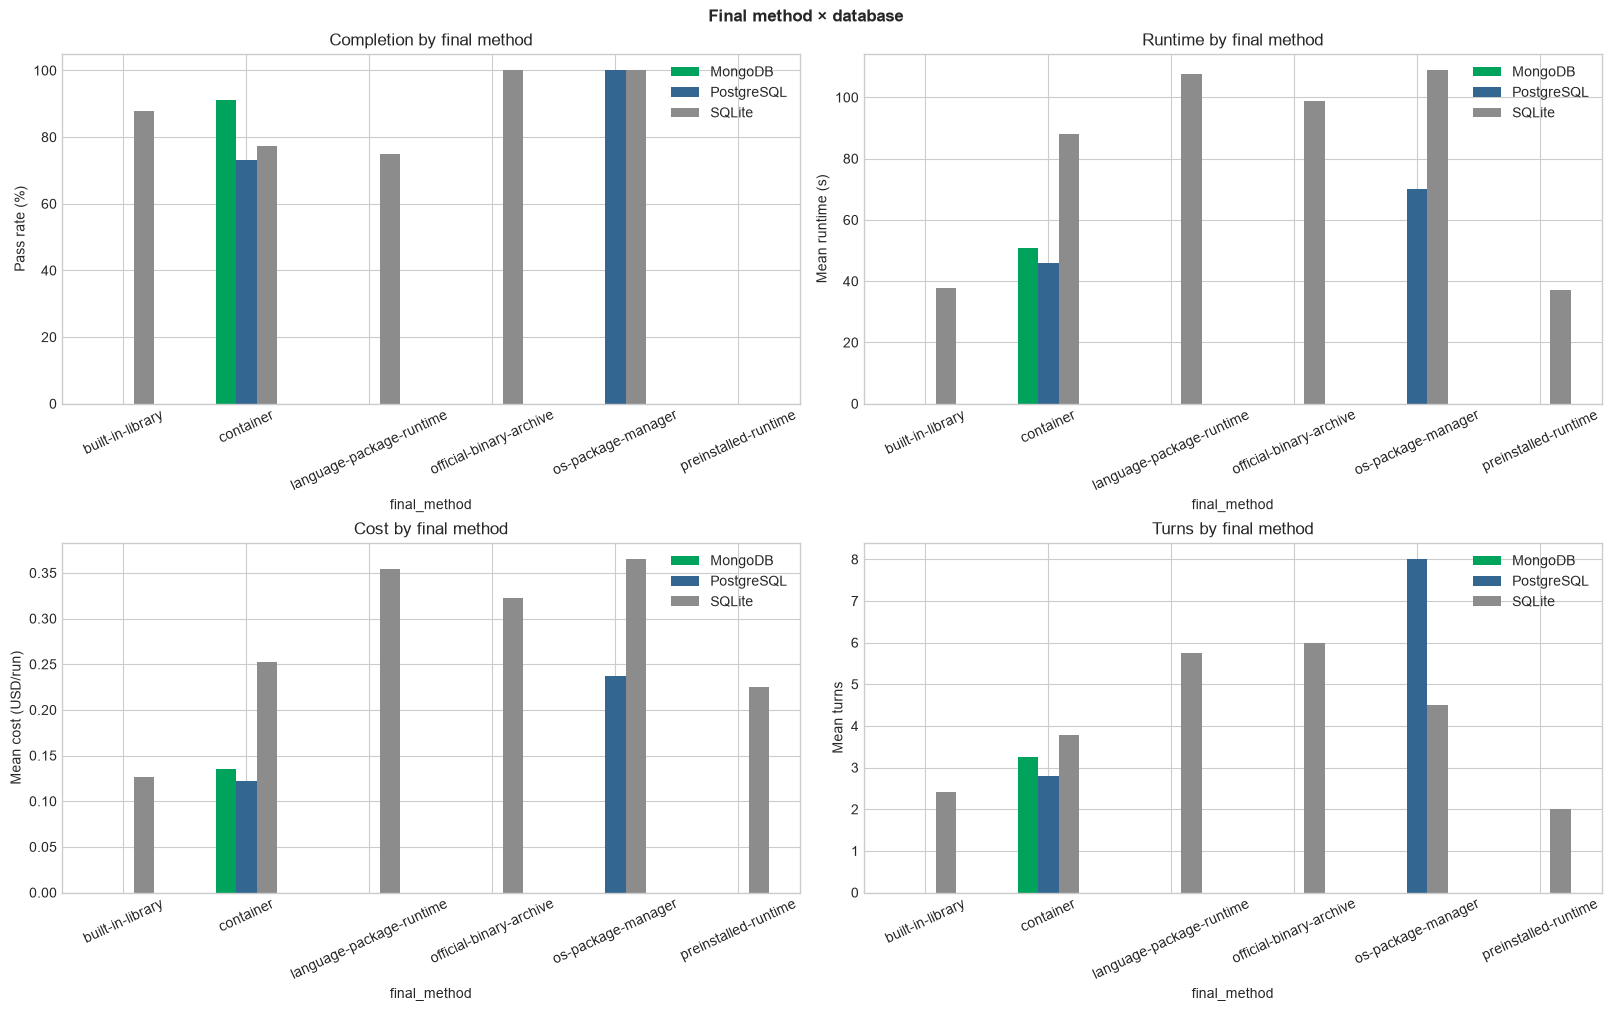

Final method by agent/model × database (counts):


,extension,database,final_method,n
0,claude-sonnet,mongodb,container,30
1,claude-sonnet,postgresql,container,30
2,claude-sonnet,sqlite,built-in-library,29
3,claude-sonnet,sqlite,preinstalled-runtime,1
4,cursor-sonnet,mongodb,container,28
5,cursor-sonnet,postgresql,container,29
6,cursor-sonnet,postgresql,os-package-manager,1
7,cursor-sonnet,sqlite,built-in-library,3
8,cursor-sonnet,sqlite,container,19
9,cursor-sonnet,sqlite,language-package-runtime,4


In [13]:
if not READY or "method_runs" not in globals() or method_runs.empty:
    print("Waiting for method classification.")
else:
    by_method = (
        method_runs.groupby(["database", "final_method"], observed=True)
        .agg(
            n=("run_id", "size"),
            pass_rate=("both_tests_passed", "mean"),
            runtime_mean=("runtime_s", "mean"),
            cost_mean=("cost_usd", "mean"),
            turns_mean=("num_turns", "mean"),
        )
        .reset_index()
    )
    by_method["pass_rate_pct"] = by_method["pass_rate"] * 100
    display(by_method.round(3))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    for ax, metric, ylabel, title in [
        (axes[0, 0], "pass_rate_pct", "Pass rate (%)", "Completion by final method"),
        (axes[0, 1], "runtime_mean", "Mean runtime (s)", "Runtime by final method"),
        (axes[1, 0], "cost_mean", "Mean cost (USD/run)", "Cost by final method"),
        (axes[1, 1], "turns_mean", "Mean turns", "Turns by final method"),
    ]:
        pivot = by_method.pivot(index="final_method", columns="database", values=metric)
        pivot.plot(
            kind="bar",
            ax=ax,
            color=[COLORS[name] for name in pivot.columns],
        )
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend([label_of(name) for name in pivot.columns], frameon=False)
        ax.tick_params(axis="x", rotation=25)
    fig.suptitle("Final method × database", fontweight="bold")
    plt.show()

    print("Final method by agent/model × database (counts):")
    display(
        method_runs.groupby(["extension", "database", "final_method"], observed=True)
        .size()
        .rename("n")
        .reset_index()
    )


## Validity flags (boolean evidence only)

Codebook flags that would drop a run from primary completion: external cloud
service, inherited credentials, pre-existing database. Counts only — no hosts,
URIs, or payloads.


In [14]:
if not READY:
    print("Waiting for measurements.")
else:
    validity_sql = f"""
    SELECT
        run_id,
        countIf(
            positionCaseInsensitive(payload, 'mongodb.net') > 0
            OR positionCaseInsensitive(payload, 'atlas.mongodb') > 0
            OR positionCaseInsensitive(payload, 'supabase') > 0
            OR positionCaseInsensitive(payload, 'neon.tech') > 0
        ) AS external_service_hits,
        countIf(positionCaseInsensitive(payload, 'MONGODB_URI') > 0
             OR positionCaseInsensitive(payload, 'DATABASE_URL') > 0) AS inherited_credential_hits
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
    GROUP BY run_id
    """
    validity = ax_query(validity_sql)
    flagged = runs.merge(validity, on="run_id", how="left")
    print("Runs with at least one matching tool-call (not event counts):")
    display(
        pd.DataFrame(
            {
                "external_service": [
                    int(flagged["external_service_hits"].fillna(0).gt(0).sum())
                ],
                "inherited_credential_hint": [
                    int(flagged["inherited_credential_hits"].fillna(0).gt(0).sum())
                ],
                "n": [len(flagged)],
            }
        )
    )


Runs with at least one matching tool-call (not event counts):


,external_service,inherited_credential_hint,n
0,0,3,443


## Docker contract (design bet)

Bet: MongoDB/PostgreSQL use ordinary `docker run -p`; SQLite stays on a file
DB. Guard hits should be 0. Leftover `--network host` is habit, not required.


In [15]:
if not READY:
    print("Waiting for measurements.")
else:
    docker_sql = f"""
    SELECT
        run_id,
        countIf(positionCaseInsensitive(payload, 'docker run') > 0) AS docker_run_hits,
        countIf(position(payload, '27017:27017') > 0 OR position(payload, '5432:5432') > 0
             OR positionCaseInsensitive(payload, '--publish') > 0
             OR match(payload, '-p [0-9]+:[0-9]+')) AS publish_port_hits,
        countIf(positionCaseInsensitive(payload, '--network host') > 0
             OR positionCaseInsensitive(payload, '--network=host') > 0) AS host_network_hits,
        countIf(positionCaseInsensitive(payload, 'Docker bridge networking is unavailable') > 0) AS guard_hits
    FROM events
    WHERE run_request_id = '{RUN_REQUEST_ID}'
      AND kind = 'tool_call'
    GROUP BY run_id
    """
    docker_flags = ax_query(docker_sql)
    docker_runs = runs.merge(docker_flags, on="run_id", how="left")
    summary_flags = (
        docker_runs.groupby("database", observed=True)
        .agg(
            n=("run_id", "size"),
            docker_run=("docker_run_hits", lambda s: s.fillna(0).gt(0).sum()),
            published_port=("publish_port_hits", lambda s: s.fillna(0).gt(0).sum()),
            host_network=("host_network_hits", lambda s: s.fillna(0).gt(0).sum()),
            guard=("guard_hits", lambda s: s.fillna(0).gt(0).sum()),
        )
        .reindex(DATABASE_ORDER)
        .reset_index()
    )
    display(summary_flags)
    print(
        f"Guard hits: {int(docker_runs['guard_hits'].fillna(0).gt(0).sum())}/{len(docker_runs)}."
    )


,database,n,docker_run,published_port,host_network,guard
0,mongodb,148,148,148,0,0
1,postgresql,150,149,148,19,0
2,sqlite,145,24,22,0,0


Guard hits: 0/443.


## Interpretation

Computed on terminal request `01KZXXQ2JPNK4XX5377TF3V8E6`: **443/450**
measurement rows, **369/443 (83.3%)** both-tests pass, **$61.32** total
(mean **$0.138/run**). Seven trials never produced measurements (2 starved,
5 sandbox-timeout past `max_time_seconds=1800`). Primary rates use measurement
rows; `test_output` is a few rows thinner on some Cursor cells.

### RQ1 — which database is easiest?

**MongoDB**, on pass rate: **135/148 (91.2%)**. PostgreSQL is the completion
gap at **110/150 (73.3%)**. SQLite sits in between at **124/145 (85.5%)** —
easy on time/cost, not uniformly easy on the official tests.

- Mongo misses are almost all `connection-verified-in-agent` (3 no-app-level-op,
  2 readiness-only in test_output). URI reporting is ceiling. The weak Mongo
  cell is **Cursor + Grok (23/30, 77%)**; Claude is 30/30, Cursor + Sonnet 27/28,
  both Terra cells 90–93%.
- Postgres misses are **readiness-only** (`pg_isready` / TCP, 33 of 34 Postgres
  connection failures). Cursor + Grok is **10/30 (33%)** and Cursor + Terra is
  **15/30 (50%)**. Claude, Cursor + Sonnet, and Codex + Terra are 93–97%.
- SQLite's drag is **Claude + Sonnet (20/30)**, mostly `uri-not-reported` (8)
  despite a file `sqlite3` / built-in-library path. Cursor + Sonnet is 24/29
  with 3 no-app-level-op connection misses.

### RQ2 — provisioning methods

Pooled across all agent/models:

- Mongo / Postgres **container** is the attempted path on essentially every
  finished trial (`docker run` 148/148 Mongo, 149/150 Postgres). Failures stay
  labeled `container` with outcome `unverified` (tests failed) or `unscored`
  (no test rows) — not a missing Docker method.
- SQLite is **built-in-library** on the file-DB path. The exception is
  **Cursor + Sonnet**, which over-provisions: 15/29 final `container`, plus a
  handful of language-package / apt / tarball paths.

By each agent/model × database, the mix is stable except that Cursor + Sonnet /
SQLite cell. Codex + Terra SQLite is mostly built-in-library plus 2 container.
Claude SQLite is still `built-in-library`; the URI misses are `unverified`,
not a different method.

Container successes are faster than the SQLite over-provision paths: Mongo
container mean 51s / 3.3 turns; SQLite built-in-library 38s / 2.3 turns;
SQLite container 92s / 3.8 turns and ~2× the cost.

### Efficiency and turns

SQLite still wins **time and cost** when the agent stays on a file DB
(Codex + Terra 26s / $0.047; Cursor + Terra 29s / $0.077). It loses when
Cursor + Sonnet docks it (98s / $0.306). Pooled across all combos, SQLite is
actually the *most expensive* database ($22.73 vs Mongo $20.08 vs Postgres
$18.51) because of that over-provision cell plus cheap Postgres *failures*.
Mongo vs Postgres runtime is close inside a combo; Postgres is not the slow
database, it is the *failing* one for two Cursor cells.

Turns are a harness signature, not a database signature:

| Combo | Mean turns |
| --- | ---: |
| Codex + Terra | 1.0 on every DB |
| Cursor + Terra | 1.0–1.2 |
| Cursor + Grok | ~3.0–3.3 |
| Cursor + Sonnet | 3.6–4.6 |
| Claude + Sonnet | 4.0–6.8 |

Codex is also cheapest (~$0.047/run). Claude is most expensive on Mongo/Postgres
($0.20–0.23) because of turn volume; Cursor + Sonnet SQLite is the cost outlier
because of method, not turns.

### Pareto

Cost and **turns** both separate the field. Time is dominated by the Cursor +
Sonnet SQLite container tail. Cheap-but-failing cells (Cursor + Grok / Terra
on Postgres) sit off the frontier: low cost, 33–50% success. Codex + Terra is
the efficiency winner on all three databases (93% × ~$0.047 × 1 turn).

### Same-model harness pairs (n=30)

- **Terra, Cursor vs Codex:** not interchangeable. Completion matches on Mongo
  and SQLite (~90–93%), but **Postgres is 15/30 vs 28/30**. Cursor is ~2× the
  cost with more tool calls, same 1-turn pattern. The Postgres gap is
  readiness-only verification, not install method.
- **Sonnet, Claude vs Cursor:** Mongo/Postgres completion matches (96–100% /
  93–97%). SQLite does not: Claude 20/30 (URI) vs Cursor 24/29 (connection +
  Docker over-provision). Cursor SQLite is 2× slower and ~1.7× cost. Turns
  stay higher on Claude.

### Docker contract

Bet holds. **Guard hits 0/443.** Mongo 148/148 published `-p`. Postgres 148/150
published `-p`, with 19 leftover `--network host` (habit, not required). SQLite
24/145 `docker run` — almost all Cursor + Sonnet over-provision. Validity flags:
0 external cloud, 3 inherited-credential hints.

### What n=5 got right

Postgres readiness-only as the completion gap; SQLite spread as a harness/method
story; Docker `-p` without the old guard; Claude vs Cursor Sonnet not equivalent.
What n=5 could not see: Cursor + Terra inherits the Grok-like Postgres verifier
failure at 50%, and Claude SQLite URI misses are a 33pp hole, not noise.
